# **Resultados y comparacion de los modelos** 

<div style="text-align: justify;">

En esta seccion se presentan los resultados de los modelos con su respectiva interpretacion

</div>

# ES & ES-HW

<div style="text-align: justify;">

En esta seccion se presentan los resultados de los modelos de suavizacion exponencial y suavizacion exponencial de Holt-Winters, El siguiente código carga y preprocesa datos de contaminación atmosférica, específicamente de concentraciones de $NO_2$ en una ubicación específica (Ubicacion 124). los datos se transforman en una serie de tiempo con frecuencia horaria y se dividen en conjuntos de entrenamiento, validación y prueba en proporciones de 70%, 15% y 15%, respectivamente.

Posteriormente, se implementan modelos de suavizado exponencial manualmente para predecir la serie de tiempo. Se incluyen variantes como el suavizado exponencial simple (ES(1)), que pondera los valores previos con un factor de suavizado alpha, y el suavizado exponencial doble (ES(2)), que además incorpora una tendencia lineal con el parámetro beta. También se incluyen modelos más avanzados como Holt-Winters (HW), en sus versiones sin tendencia, con tendencia aditiva y con tendencia multiplicativa. Estos modelos incorporan un rolling window para realizar predicciones y sus resultados seran comparados entre si.

</div>

ES(1) -> RMSE=0.008, MAPE=26.25%


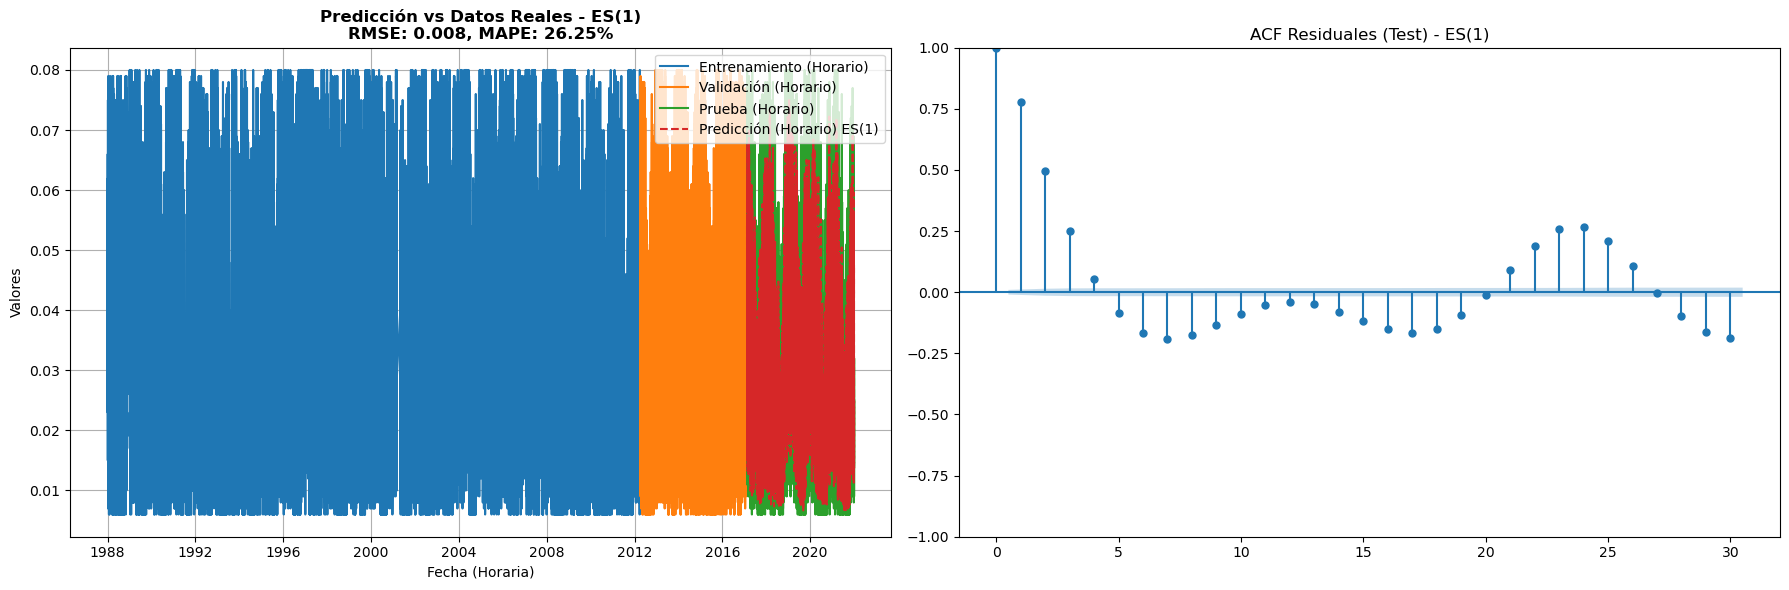

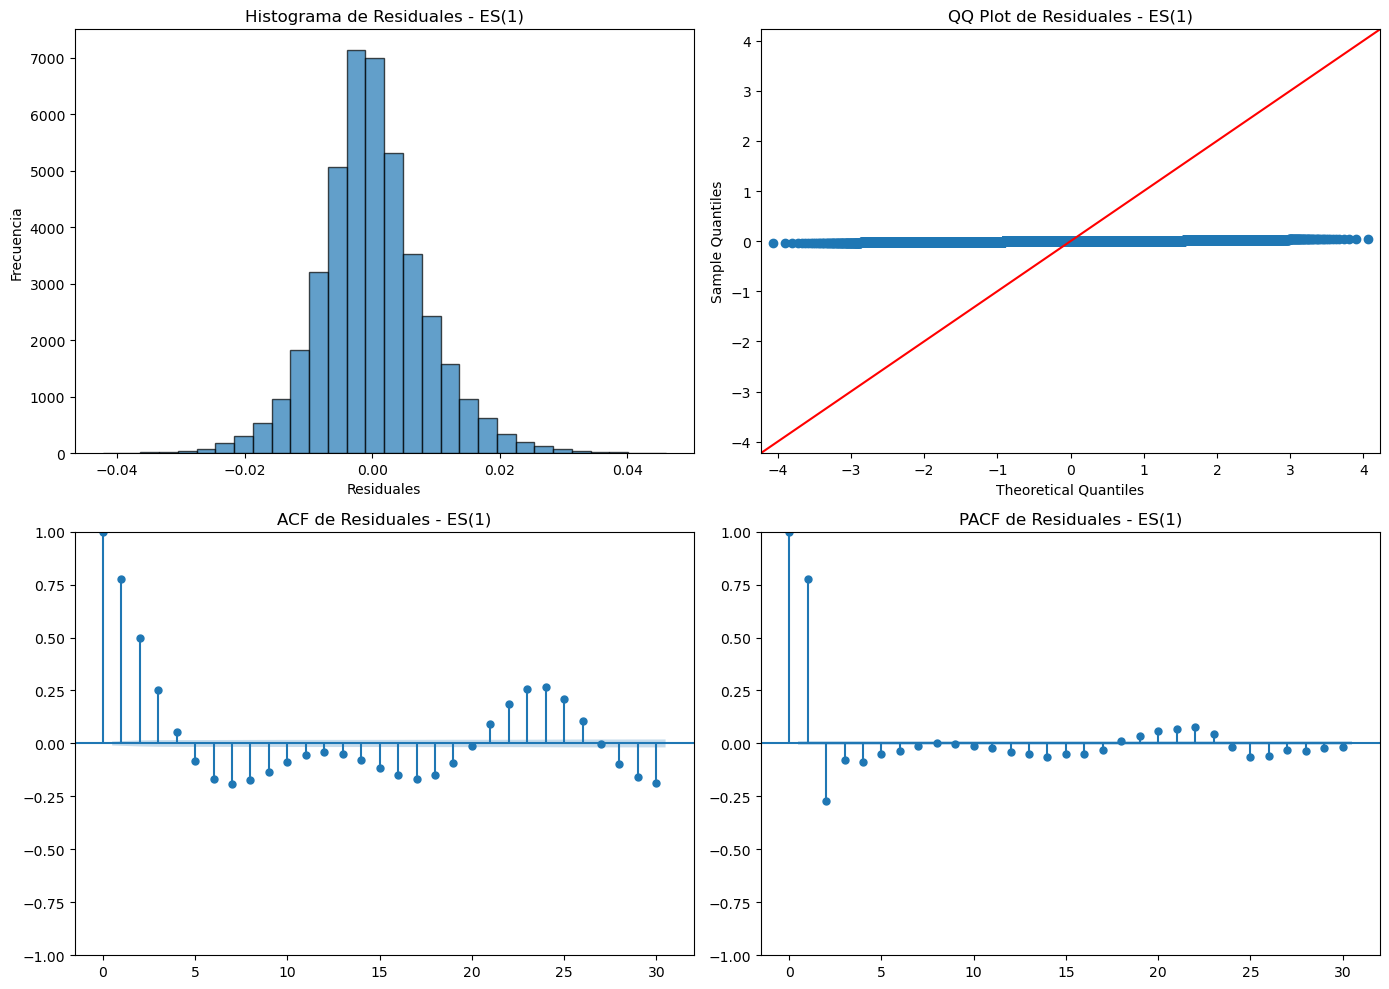

ES(2) -> RMSE=0.009, MAPE=27.83%


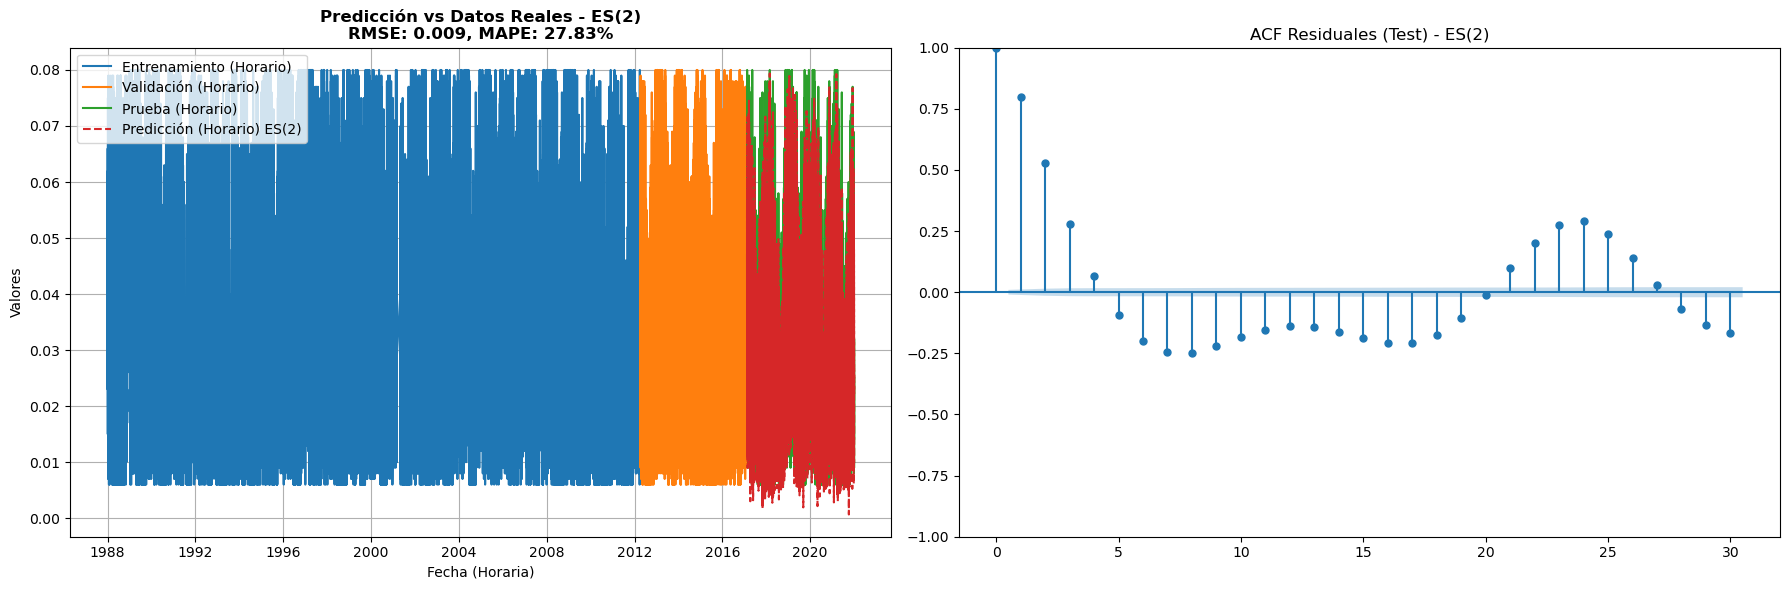

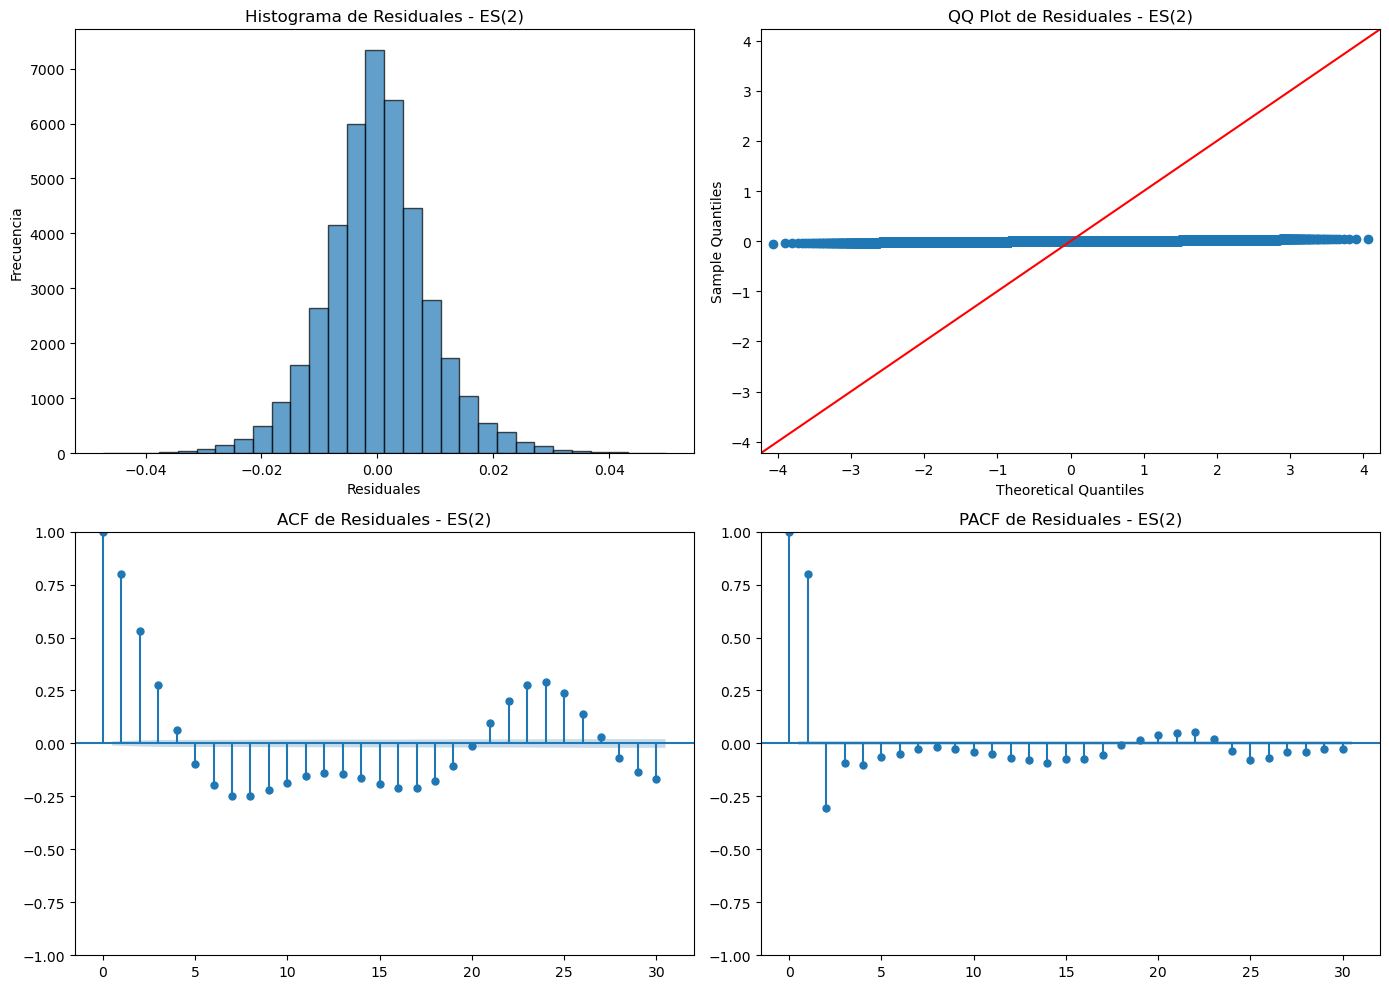

ES-HW(1) -> RMSE=0.008, MAPE=25.41%


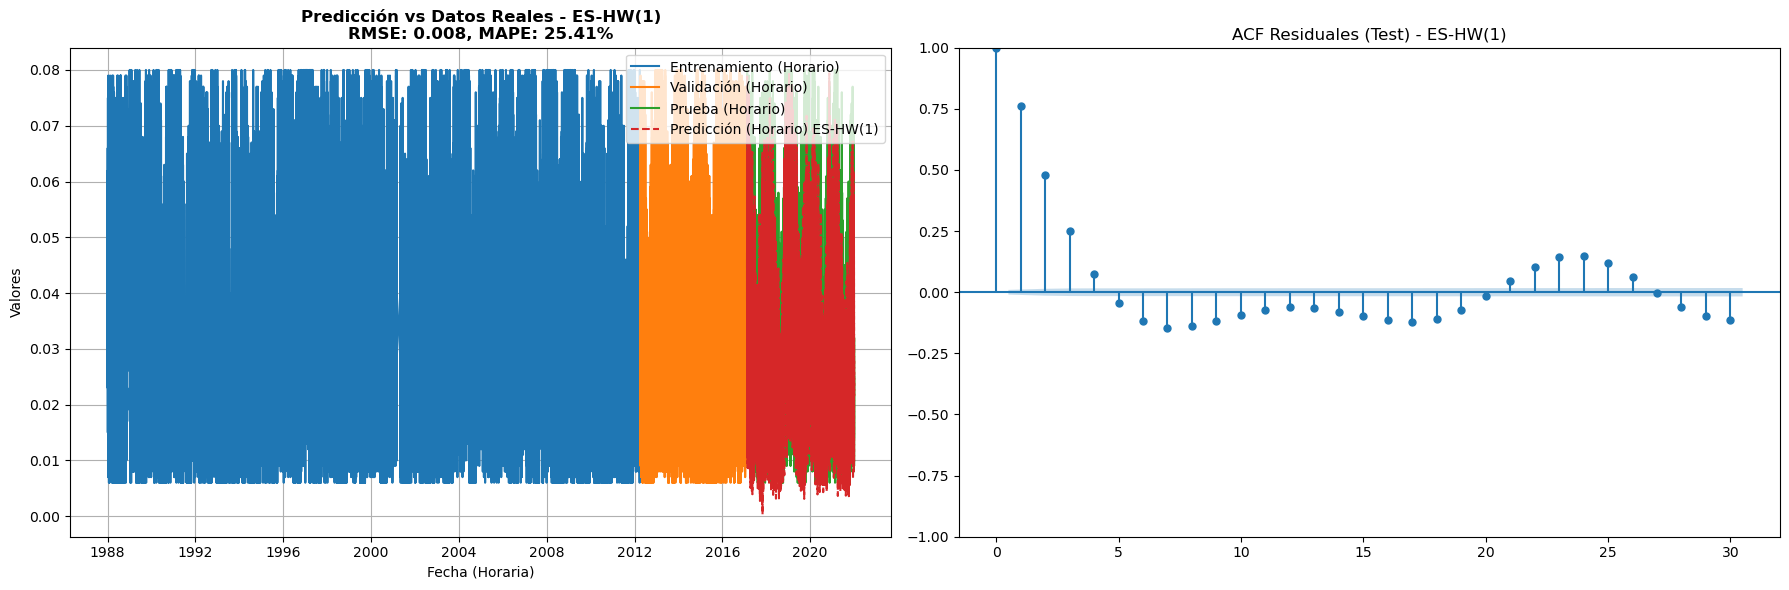

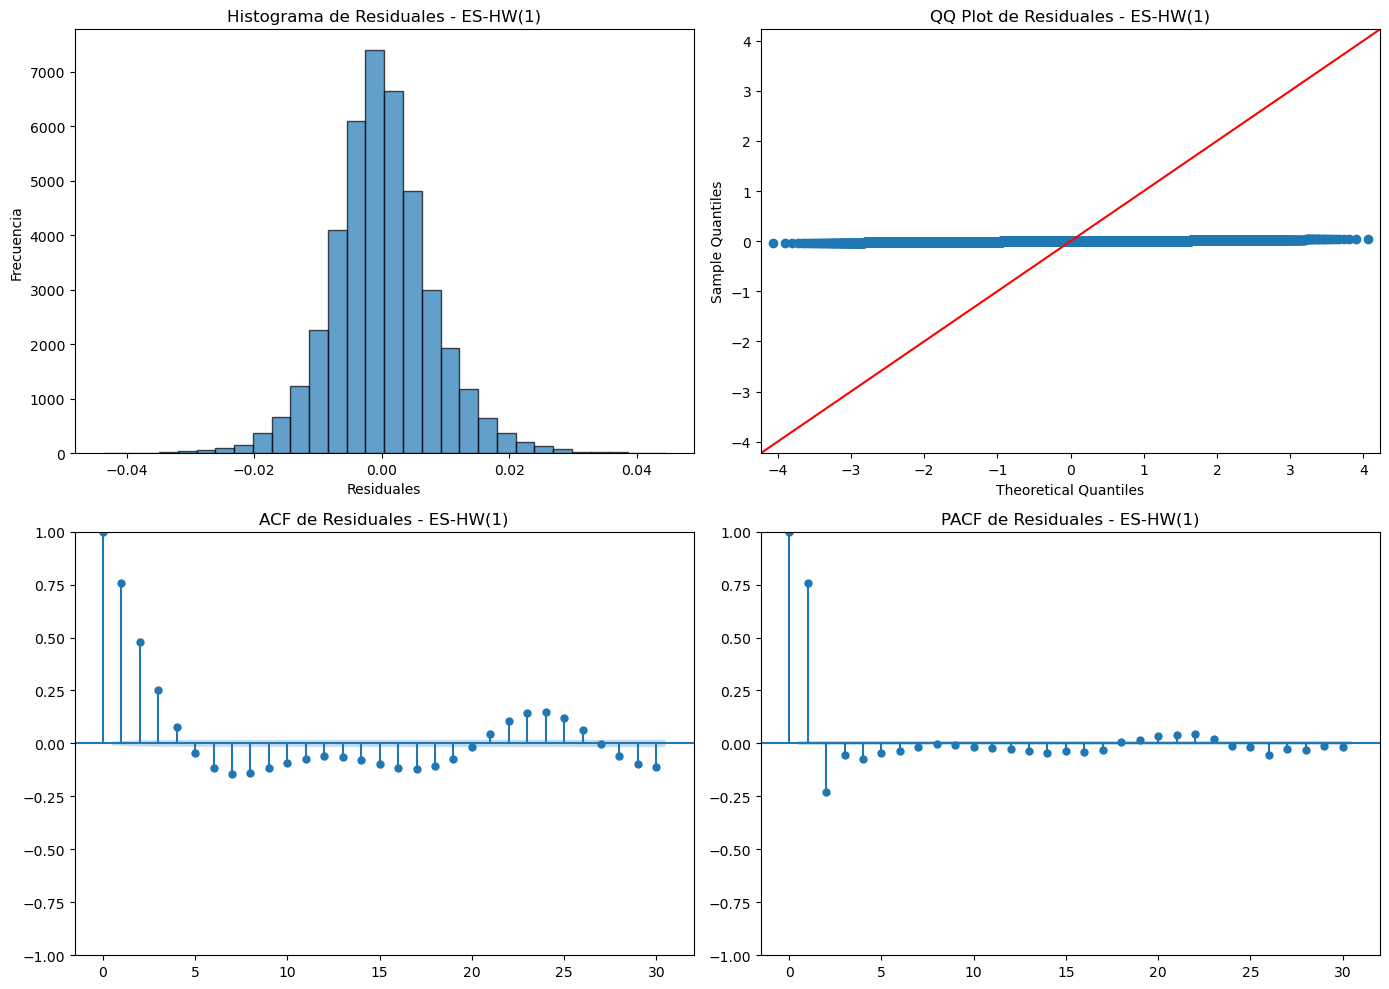

ES-HW(2) -> RMSE=0.009, MAPE=27.55%


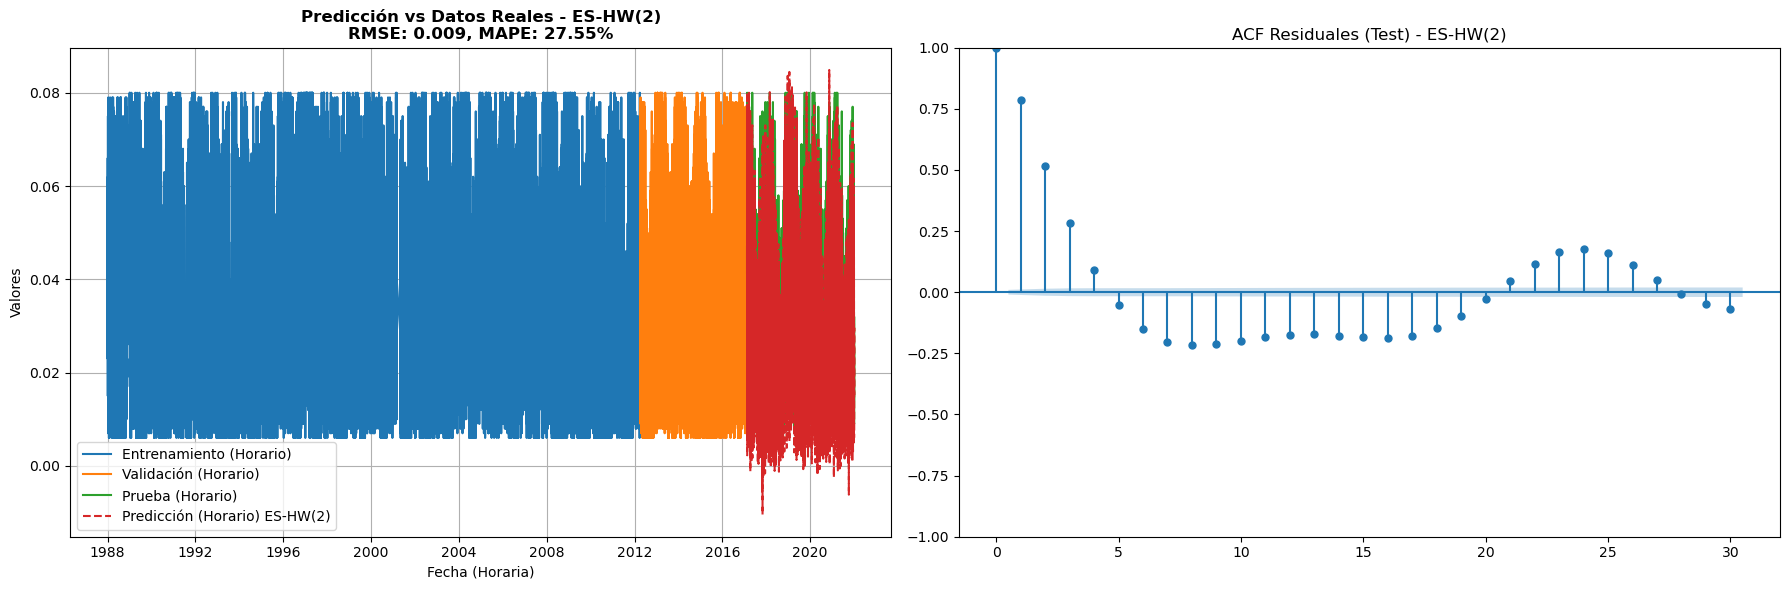

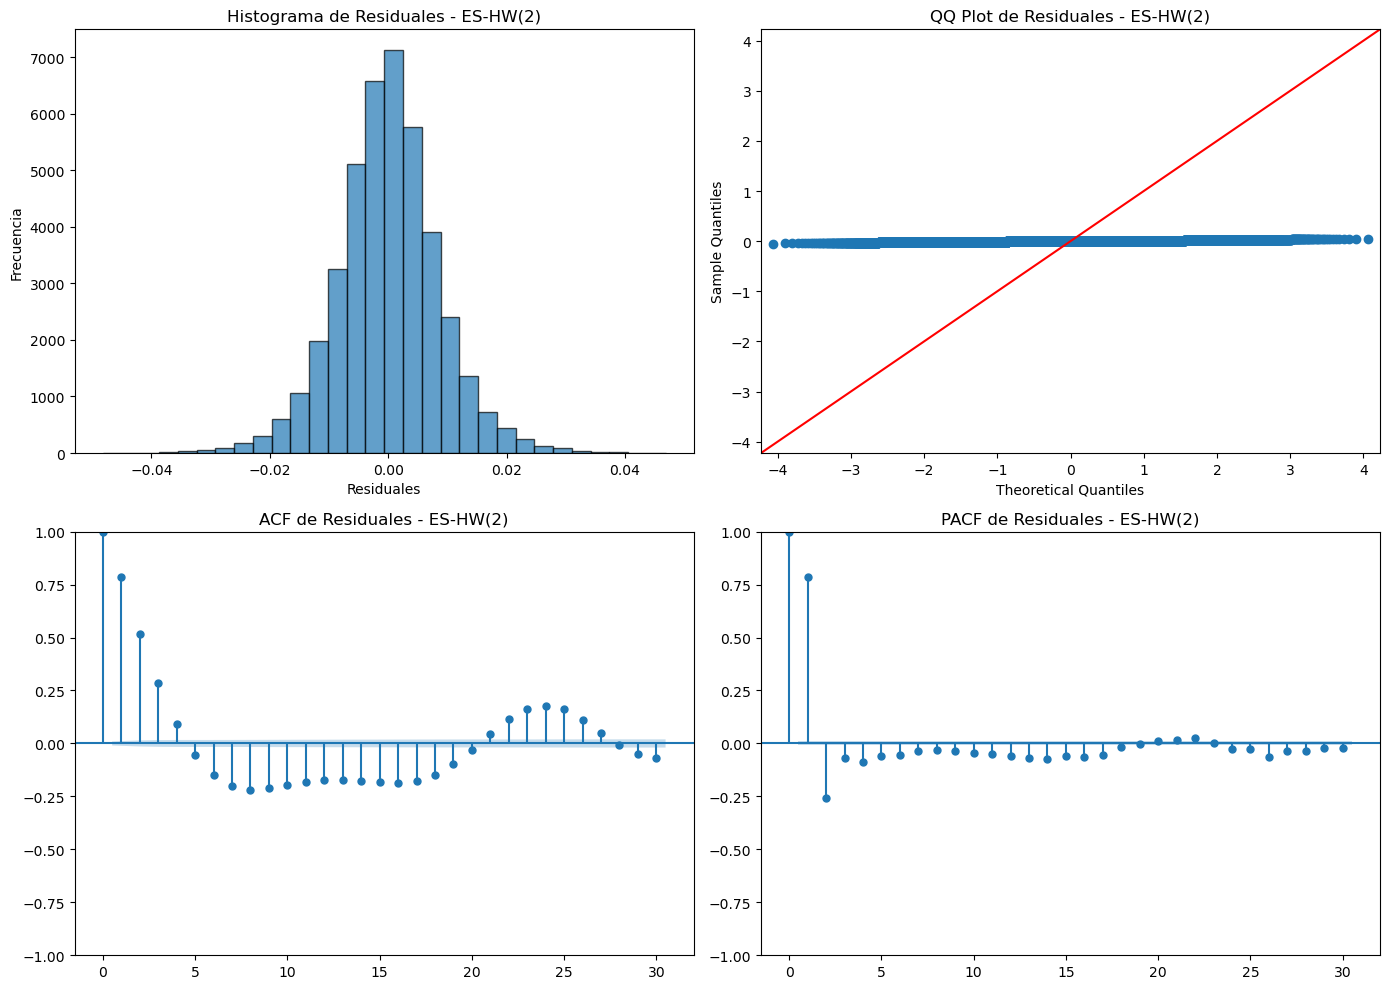

ES-HW(3) -> RMSE=0.009, MAPE=27.11%


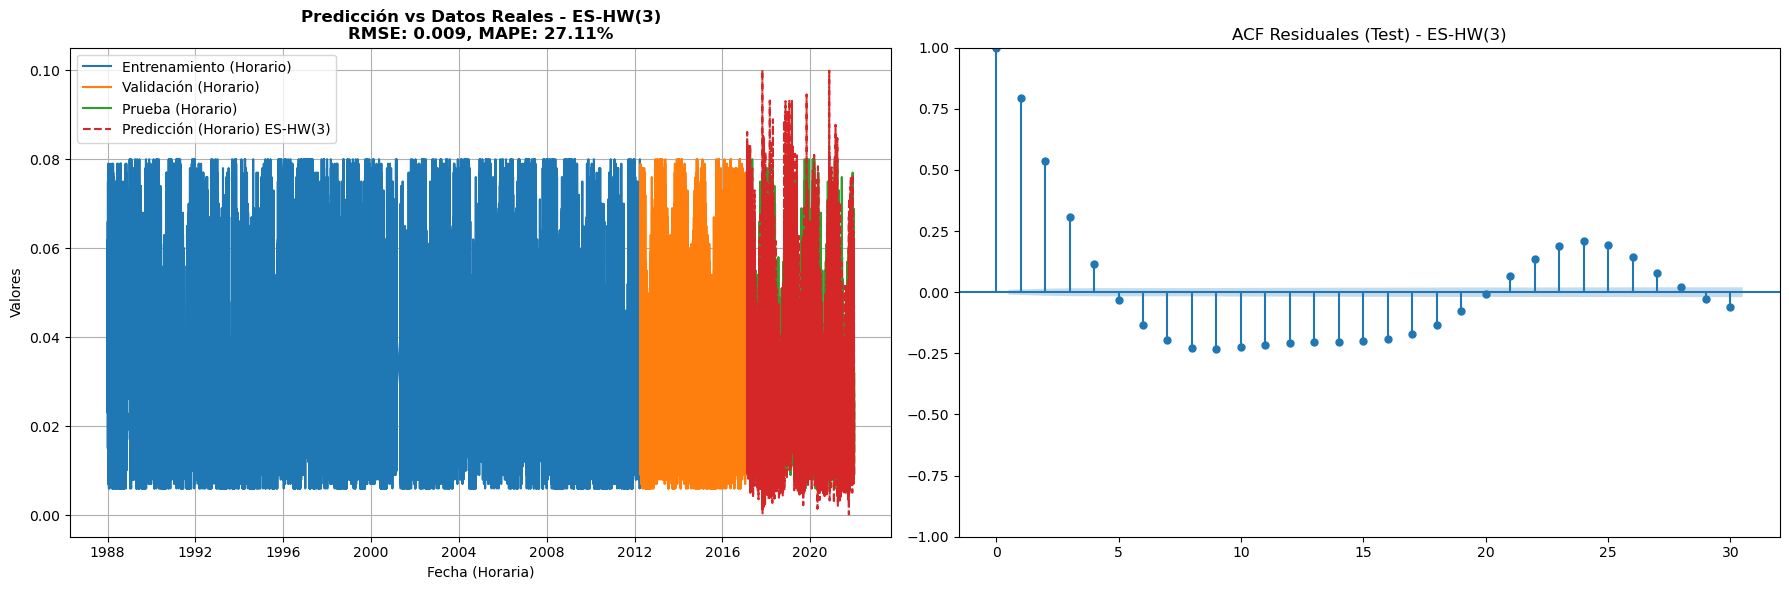

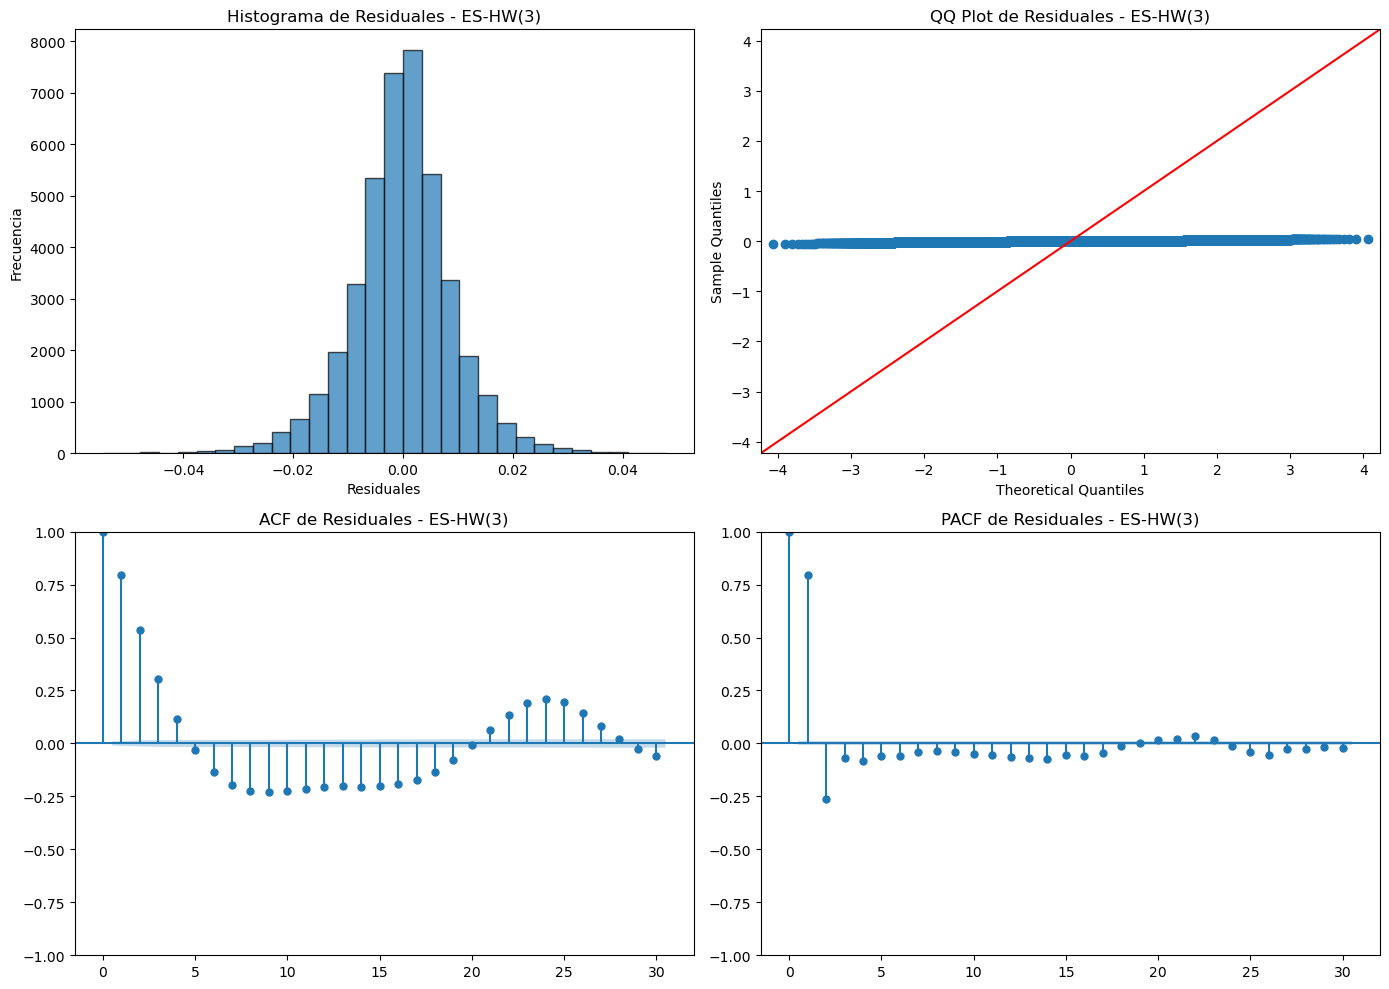


Métricas de todos los modelos:
     Modelo       MSE      RMSE       MAE   MAPE (%)  LjungBox_pvalue
0     ES(1)  0.000069  0.008323  0.006235  26.251096              0.0
1     ES(2)  0.000082  0.009080  0.006800  27.831877              0.0
2  ES-HW(1)  0.000063  0.007933  0.005967  25.409810              0.0
3  ES-HW(2)  0.000075  0.008662  0.006541  27.552487              0.0
4  ES-HW(3)  0.000082  0.009063  0.006709  27.107845              0.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

##########################
# Funciones de preprocesamiento
##########################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar loc=124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (1% y 99%)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a índice de tiempo
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()

    # División de datos
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)

    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size: train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##########################
# Modelos de Suavizado Exponencial
##########################
def manual_es1_rolling(train_series, test_series, alpha=0.2):
    """
    ES(1): Suavizado exponencial simple.
    S_t = alpha*y_t + (1 - alpha)*S_{t-1}
    """
    S_prev = train_series.iloc[-1]
    preds = []
    for t in test_series.index:
        yhat = S_prev
        preds.append(yhat)
        y_t = test_series.loc[t]
        S_prev = alpha * y_t + (1 - alpha) * S_prev
    return pd.Series(preds, index=test_series.index)

def manual_es2_rolling(train_series, test_series, alpha=0.2, beta=0.1):
    """
    ES(2): Suavizado exponencial doble (aditivo).
    L_t = alpha*y_t + (1 - alpha)*(L_{t-1} + T_{t-1})
    T_t = beta*(L_t - L_{t-1}) + (1 - beta)*T_{t-1}
    Pronóstico: ŷ_t = L_{t-1} + T_{t-1}
    """
    L_prev = train_series.iloc[-1]
    if len(train_series) >= 2:
        T_prev = train_series.iloc[-1] - train_series.iloc[-2]
    else:
        T_prev = 0
    preds = []
    for t in test_series.index:
        yhat = L_prev + T_prev
        preds.append(yhat)
        y_t = test_series.loc[t]
        L_new = alpha * y_t + (1 - alpha) * (L_prev + T_prev)
        T_new = beta * (L_new - L_prev) + (1 - beta) * T_prev
        L_prev, T_prev = L_new, T_new
    return pd.Series(preds, index=test_series.index)

def manual_eshw1_rolling(train_series, test_series, alpha=0.2, gamma=0.1, m=24):
    """
    ES-HW(1): Holt-Winters sin tendencia (modelo aditivo sin tendencia).
    Nivel: L_t = alpha*(y_t - S_{t-m}) + (1 - alpha)*L_{t-1}
    Estacionalidad: S_t = gamma*(y_t - L_t) + (1 - gamma)*S_{t-m}
    Pronóstico: ŷ_t = L_{t-1} + S_{t-m+1}
    """
    if len(train_series) < m:
        raise ValueError("Se requieren al menos m observaciones en entrenamiento.")
    last_cycle = train_series.iloc[-m:]
    L_prev = last_cycle.mean()
    seasonal = list(last_cycle - L_prev)
    preds = []
    for i, t in enumerate(test_series.index):
        season_idx = i % m
        yhat = L_prev + seasonal[season_idx]
        preds.append(yhat)
        y_t = test_series.loc[t]
        L_new = alpha * (y_t - seasonal[season_idx]) + (1 - alpha) * L_prev
        S_new = gamma * (y_t - L_new) + (1 - gamma) * seasonal[season_idx]
        L_prev = L_new
        seasonal[season_idx] = S_new
    return pd.Series(preds, index=test_series.index)

def manual_eshw2_rolling(train_series, test_series, alpha=0.2, beta=0.1, gamma=0.1, m=24):
    """
    ES-HW(2): Holt-Winters aditivo con tendencia y estacionalidad.
    Nivel: L_t = alpha*(y_t - S_{t-m}) + (1 - alpha)*(L_{t-1} + T_{t-1})
    Tendencia: T_t = beta*(L_t - L_{t-1}) + (1 - beta)*T_{t-1}
    Estacionalidad: S_t = gamma*(y_t - L_t - T_t) + (1 - gamma)*S_{t-m}
    Pronóstico: ŷ_t = L_{t-1} + T_{t-1} + S_{t-m+1}
    """
    if len(train_series) < m+1:
        raise ValueError("Se requieren al menos m+1 observaciones en entrenamiento.")
    last_cycle = train_series.iloc[-m:]
    L_prev = last_cycle.mean()
    T_prev = (last_cycle.iloc[-1] - last_cycle.iloc[0]) / (m - 1)
    seasonal = list(last_cycle - L_prev)
    preds = []
    for i, t in enumerate(test_series.index):
        season_idx = i % m
        yhat = L_prev + T_prev + seasonal[season_idx]
        preds.append(yhat)
        y_t = test_series.loc[t]
        L_new = alpha * (y_t - seasonal[season_idx]) + (1 - alpha) * (L_prev + T_prev)
        T_new = beta * (L_new - L_prev) + (1 - beta) * T_prev
        S_new = gamma * (y_t - L_new - T_new) + (1 - gamma) * seasonal[season_idx]
        L_prev, T_prev = L_new, T_new
        seasonal[season_idx] = S_new
    return pd.Series(preds, index=test_series.index)

def manual_eshw3_rolling(train_series, test_series, alpha=0.2, beta=0.1, gamma=0.1, m=24):
    """
    ES-HW(3): Holt-Winters multiplicativo con tendencia y estacionalidad.
    Nivel: L_t = alpha*(y_t / S_{t-m}) + (1 - alpha)*(L_{t-1} + T_{t-1})
    Tendencia: T_t = beta*(L_t - L_{t-1}) + (1 - beta)*T_{t-1}
    Estacionalidad: S_t = gamma*(y_t / (L_t + T_t)) + (1 - gamma)*S_{t-m}
    Pronóstico: ŷ_t = (L_{t-1} + T_{t-1}) * S_{t-m+1}
    """
    if len(train_series) < m+1:
        raise ValueError("Se requieren al menos m+1 observaciones en entrenamiento.")
    last_cycle = train_series.iloc[-m:]
    L_prev = last_cycle.mean()
    T_prev = (last_cycle.iloc[-1] - last_cycle.iloc[0]) / (m - 1)
    seasonal = list(last_cycle / L_prev)
    preds = []
    for i, t in enumerate(test_series.index):
        season_idx = i % m
        yhat = (L_prev + T_prev) * seasonal[season_idx]
        preds.append(yhat)
        y_t = test_series.loc[t]
        L_new = alpha * (y_t / seasonal[season_idx]) + (1 - alpha) * (L_prev + T_prev)
        T_new = beta * (L_new - L_prev) + (1 - beta) * T_prev
        S_new = gamma * (y_t / (L_new + T_new)) + (1 - gamma) * seasonal[season_idx]
        L_prev, T_prev = L_new, T_new
        seasonal[season_idx] = S_new
    return pd.Series(preds, index=test_series.index)

##########################
# Función para graficar resultados y análisis de residuos
##########################
def plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape):
    """
    La primera gráfica muestra la comparación de datos crudos (horarios) del conjunto de 
    entrenamiento, validación y prueba frente a las predicciones. Después se visualiza la 
    ACF de residuales, y en la segunda figura se muestran Histograma, QQ Plot, ACF y PACF 
    de los residuales.
    """
    # FIGURA 1: Predicción vs Datos Reales (DATOS HORARIOS) + ACF de los residuales
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfico de Predicción vs Datos Reales (RAW)
    axes[0].plot(train.index, train.values, label="Entrenamiento (Horario)")
    axes[0].plot(validation.index, validation.values, label="Validación (Horario)")
    axes[0].plot(test.index, test.values, label="Prueba (Horario)")
    axes[0].plot(prediction_series.index, prediction_series.values, '--', label=f"Predicción (Horario) {model_name}")
    
    axes[0].set_title(f"Predicción vs Datos Reales - {model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%", 
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Fecha (Horaria)")
    axes[0].set_ylabel("Valores")
    axes[0].legend()
    axes[0].grid(True)
    
    # ACF de los residuales del test (en resolución horaria, sin resample)
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF Residuales (Test) - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # FIGURA 2: Histograma, QQ Plot, ACF y PACF de los residuales (datos horarios)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histograma de los residuales
    axes[0, 0].hist(model_residuals.dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f"Histograma de Residuales - {model_name}")
    axes[0, 0].set_xlabel("Residuales")
    axes[0, 0].set_ylabel("Frecuencia")
    
    # QQ Plot de los residuales
    sm.qqplot(model_residuals.dropna(), line='45', ax=axes[0, 1])
    axes[0, 1].set_title(f"QQ Plot de Residuales - {model_name}")
    
    # ACF de los residuales
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title(f"ACF de Residuales - {model_name}")
    
    # PACF de los residuales
    plot_pacf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title(f"PACF de Residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##########################
# Función principal
##########################
def main():
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # Para los pronósticos "rolling" se combinan Train y Validación
    train_val = pd.concat([train, validation])
    
    # Parámetros comunes
    alpha = 0.2
    beta = 0.1
    gamma = 0.1
    m = 24  # Período estacional (24 horas)
    
    # Obtener predicciones para cada modelo
    models = {
        "ES(1)": manual_es1_rolling(train_val, test, alpha=alpha),
        "ES(2)": manual_es2_rolling(train_val, test, alpha=alpha, beta=beta),
        "ES-HW(1)": manual_eshw1_rolling(train_val, test, alpha=alpha, gamma=gamma, m=m),
        "ES-HW(2)": manual_eshw2_rolling(train_val, test, alpha=alpha, beta=beta, gamma=gamma, m=m),
        "ES-HW(3)": manual_eshw3_rolling(train_val, test, alpha=alpha, beta=beta, gamma=gamma, m=m)
    }
    
    # DataFrame para almacenar las métricas de cada modelo
    metrics_list = []

    # Iterar sobre cada modelo para calcular métricas y graficar resultados
    for model_name, prediction_series in models.items():
        # Alinear datos y calcular métricas
        y_true, y_pred = test.align(prediction_series, join='inner')
        mask = y_true.notnull() & y_pred.notnull()
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        
        # Calcular residuales (observado - predicción)
        model_residuals = y_true - y_pred
        
        # Ljung-Box test (p-value) usando 20 rezagos
        lb_test = acorr_ljungbox(model_residuals.dropna(), lags=[20], return_df=True)
        ljung_box_pvalue = lb_test['lb_pvalue'].values[0]

        print(f"{model_name} -> RMSE={rmse:.3f}, MAPE={mape:.2f}%")
        
        # Guardamos en la lista de métricas
        metrics_list.append({
            "Modelo": model_name,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE (%)": mape,
            "LjungBox_pvalue": ljung_box_pvalue
        })
        
        # Graficar resultados y análisis de residuales (datos horarios)
        plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape)

    # Convertir la lista de métricas en un DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    print("\nMétricas de todos los modelos:")
    print(metrics_df)

if __name__ == "__main__":
    main()

<div style="text-align: justify;">

El análisis de los modelos de suavizamiento exponencial y Holt-Winters revela diferencias en su desempeño, medido a través del RMSE y el MAPE. El modelo ES-HW(3) tiene un RMSE de 0.009 y un MAPE del 27.11%, lo que indica un nivel de error similar al ES-HW(2) y ES(2), aunque es ligeramente superior a ES-HW(1), que muestra el menor RMSE y MAPE entre los modelos evaluados.

Las gráficas de predicción contra los datos reales muestran que los modelos sigue adecuadamente la tendencia general, aunque en la fase de prueba la predicción presenta mayor variabilidad. La ACF de los residuos sugiere que existe autocorrelación significativa, lo cual indica que los modelos no ha capturado completamente la estructura temporal de los datos. Esto se refuerza con los valores p de la prueba de Ljung-Box, que son 0 en todos los modelos, lo que implica que los residuos no son completamente aleatorios y aún contienen información predecible.

Los historgramas de residuos sugieren que los errores tienen una distribución aproximadamente normal, aunque el QQ plot y la prueba de shapiro wilk confirma que no son normales. La ACF y PACF de los residuos confirman que hay correlaciones significativas en los primeros rezagos, lo que sugiere que el modelo no ha eliminado completamente la dependencia temporal.

</div>

# ARIMA 

<div style="text-align: justify;">

El modelo ARIMA se ajustó utilizando una transformación logarítmica para estabilizar la varianza de la serie temporal. La serie se dividió en conjuntos de entrenamiento, validación y prueba, con un 70% de los datos para entrenamiento y un 15% para validación y prueba, respectivamente. El modelo se reentrenó cada 50 pasos utilizando una ventana de 500 puntos históricos. Las predicciones se realizaron en la escala logarítmica y luego se transformaron de nuevo a la escala original.

</div>

Rolling ARIMA Forecast:   0%|                                                                 | 0/1798 [00:00<?, ?it/s]C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
Rolling ARIMA Forecast:   0%|                                                         | 1/1798 [00:00<04:44,  6.32it/s]C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


--- Resultados Rolling ARIMA (log-transform) ---
MAE :  0.009
MSE :  0.000
RMSE:  0.012
MAPE:  37.90%

Prueba de Ljung-Box (lag=10 y 20):
        lb_stat  lb_pvalue
10  2067.922778        0.0
20  2984.674306        0.0


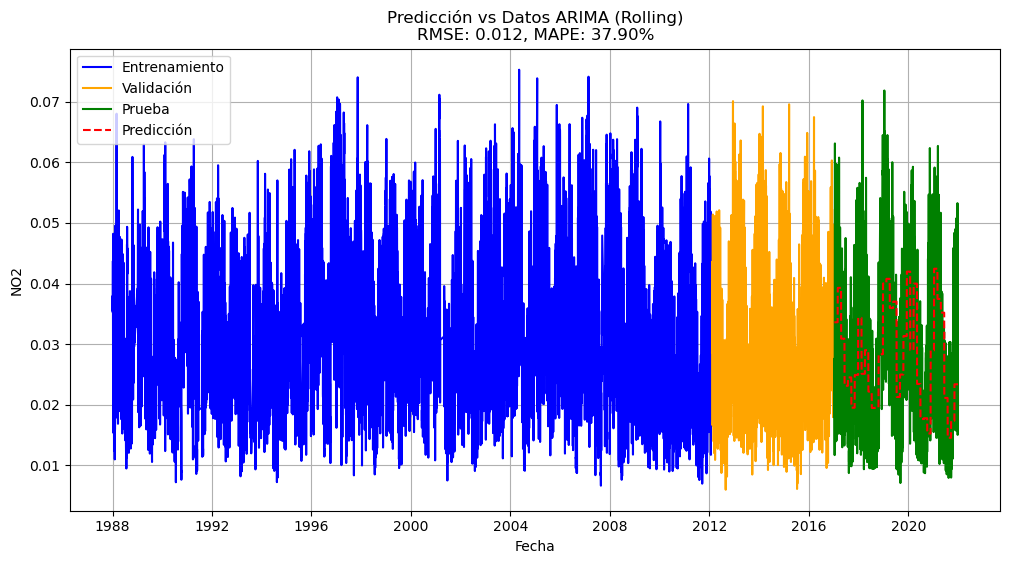

<Figure size 800x400 with 0 Axes>

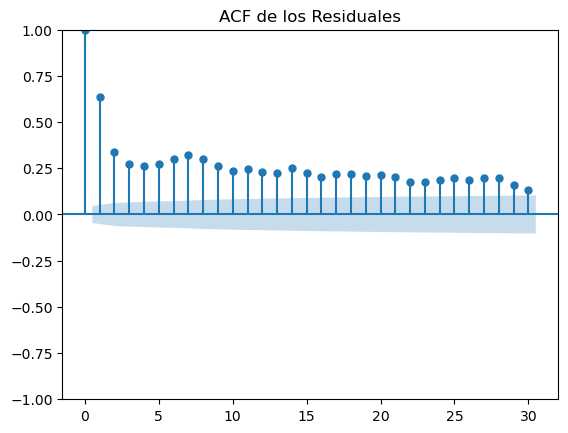

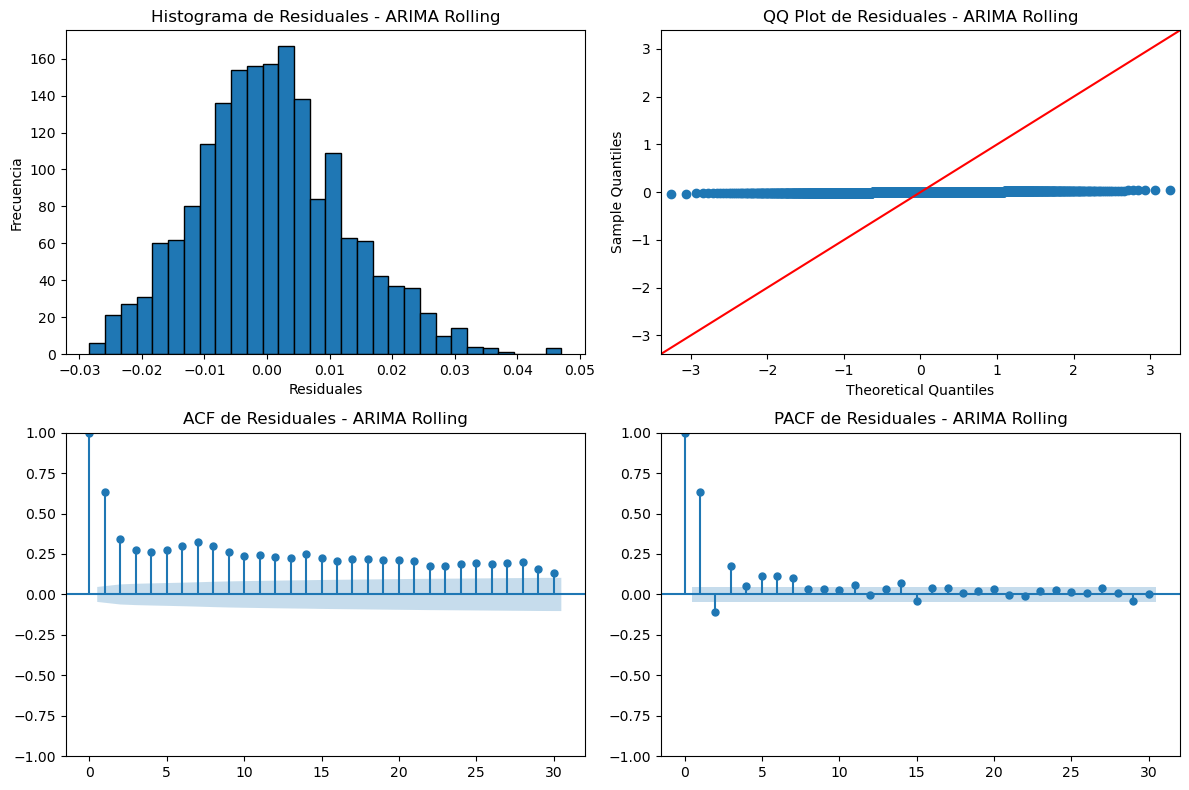

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error,
                             mean_absolute_percentage_error)

# Para análisis de residuales
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox

# ARIMA de statsmodels
import statsmodels.api as sm

###############################################
# 1) Función para cargar y preprocesar datos
#    con opción de agregación diaria
###############################################
def load_and_preprocess_data(csv_path, resample_daily=True):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc = 124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    
    # Convertir a frecuencia horaria y eliminar huecos
    data_hourly = data['no2'].asfreq('H').dropna()
    
    # (OPCIONAL) Re-muestrear a diario para suavizar la serie
    if resample_daily:
        data_resampled = data_hourly.resample('D').mean().dropna()
    else:
        data_resampled = data_hourly

    # División en entrenamiento (70%), validación (15%) y prueba (15%)
    n = len(data_resampled)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_resampled.iloc[:train_size]
    validation = data_resampled.iloc[train_size: train_size + val_size]
    test = data_resampled.iloc[train_size + val_size:]
    
    return train, validation, test

###############################################
# 2) Transformaciones logarítmicas (opcional)
###############################################
def log_transform(series):
    # log(1 + x) para evitar problemas si hay valores muy pequeños/cercanos a 0
    return np.log1p(series)

def inverse_log_transform(series):
    return np.expm1(series)

###############################################
# 3) Rolling Forecast con ARIMA (log-scale)
###############################################
def rolling_arima_forecast_log(train_series_log, test_series_log, 
                               order=(1,1,1), re_fit_freq=100, 
                               window_size=500):
    """
    Realiza un pronóstico rolling con ARIMA en la escala log:
      - reentrena cada 're_fit_freq' pasos,
      - utiliza un 'window_size' como historial.
    """
    history_log = train_series_log.copy()
    predictions_log = []
    current_fit = None

    # Iteramos sobre el test
    for idx, t in tqdm(enumerate(test_series_log.index),
                       total=len(test_series_log), 
                       desc="Rolling ARIMA Forecast"):
        # Cada 're_fit_freq' pasos (o al inicio), reentrenamos
        if idx % re_fit_freq == 0 or current_fit is None:
            # Seleccionar la ventana de entrenamiento
            if len(history_log) > window_size:
                fit_series = history_log[-window_size:]
            else:
                fit_series = history_log
            
            # Ajustar ARIMA en la ventana
            model = sm.tsa.ARIMA(fit_series, order=order)
            current_fit = model.fit()
        
        # Pronosticar 1 paso
        yhat_log = current_fit.forecast(steps=1).iloc[0]
        predictions_log.append(yhat_log)
        
        # Actualizar historial con el valor real
        real_log_value = test_series_log.loc[t]
        history_log = pd.concat([history_log, pd.Series([real_log_value], index=[t])])
    
    return pd.Series(predictions_log, index=test_series_log.index)

###############################################
# 4) Gráfica de resultados de la serie
###############################################
def plot_results(train, validation, test, predictions, rmse, mape, title="Predicción ARIMA"):
    plt.figure(figsize=(12,6))
    plt.plot(train.index, train.values, label="Entrenamiento", color='blue')
    plt.plot(validation.index, validation.values, label="Validación", color='orange')
    plt.plot(test.index, test.values, label="Prueba", color='green')
    plt.plot(predictions.index, predictions.values, '--', label="Predicción", color='red')
    plt.title(f"{title}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%")
    plt.xlabel("Fecha")
    plt.ylabel("NO2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # ACF de residuales
    residuals = test.loc[predictions.index] - predictions
    plt.figure(figsize=(8,4))
    plot_acf(residuals.dropna(), lags=30, alpha=0.05)
    plt.title("ACF de los Residuales")
    plt.show()

###############################################
# 5) Gráfica de análisis de residuales
###############################################
def plot_residual_analysis(residuals, title="ARIMA"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Histograma
    axes[0,0].hist(residuals.dropna(), bins=30, edgecolor='black')
    axes[0,0].set_title(f"Histograma de Residuales - {title}")
    axes[0,0].set_xlabel("Residuales")
    axes[0,0].set_ylabel("Frecuencia")

    # QQ Plot
    qqplot(residuals.dropna(), line='45', ax=axes[0,1])
    axes[0,1].set_title(f"QQ Plot de Residuales - {title}")

    # ACF
    plot_acf(residuals.dropna(), lags=30, alpha=0.05, ax=axes[1,0])
    axes[1,0].set_title(f"ACF de Residuales - {title}")

    # PACF
    plot_pacf(residuals.dropna(), lags=30, alpha=0.05, ax=axes[1,1])
    axes[1,1].set_title(f"PACF de Residuales - {title}")

    plt.tight_layout()
    plt.show()

###############################################
# 6) Función principal
###############################################
def main():
    # Ajusta la ruta a tu CSV
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # 1. Carga y preprocesa (usa resample_daily=False si quieres datos horarios)
    train, validation, test = load_and_preprocess_data(csv_path, resample_daily=True)
    
    # 2. Transformación log (opcional para estabilizar varianza)
    train_log = log_transform(train)
    val_log   = log_transform(validation)
    test_log  = log_transform(test)
    
    # Unir train + validation
    train_val_log = pd.concat([train_log, val_log])
    
    # 3. Rolling forecast ARIMA (log-scale)
    predictions_log = rolling_arima_forecast_log(
        train_val_log, 
        test_log, 
        order=(1,1,1),
        re_fit_freq=50,   # reentrenar cada 50 pasos (ajusta a tu gusto)
        window_size=500   # usar 500 puntos de ventana (ajusta a tu gusto)
    )
    
    # Invertir log
    predictions = inverse_log_transform(predictions_log)
    
    # Alinear test y predicciones
    test_aligned = test.loc[predictions.index]

    # 4. Métricas
    rmse = np.sqrt(mean_squared_error(test_aligned, predictions))
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    mae  = mean_absolute_error(test_aligned, predictions)
    mse  = mean_squared_error(test_aligned, predictions)
    
    # Prueba de Ljung-Box
    residuals = test_aligned - predictions
    ljung_results = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)

    # Mostrar resultados
    print("\n--- Resultados Rolling ARIMA (log-transform) ---")
    print(f"MAE :  {mae:.3f}")
    print(f"MSE :  {mse:.3f}")
    print(f"RMSE:  {rmse:.3f}")
    print(f"MAPE:  {mape:.2f}%")
    print("\nPrueba de Ljung-Box (lag=10 y 20):")
    print(ljung_results)
    
    # 5. Gráficas
    plot_results(train, validation, test, predictions, rmse, mape, 
                 title="Predicción vs Datos ARIMA (Rolling)")
    plot_residual_analysis(residuals.dropna(), title="ARIMA Rolling")

if __name__ == "__main__":
    main()

<div style="text-align: justify;">

El error cuadrático medio (RMSE) fue de 0.012, lo que indica que las predicciones están relativamente cerca de los valores reales, aunque el error porcentual absoluto medio (MAPE) del 37.90% sugiere que hay una variabilidad significativa en los errores de predicción. Esto podría deberse a la presencia de valores atípicos o a la complejidad de la serie temporal.

El histograma de los residuos muestra una distribución aproximadamente normal, sin embargo, el qq-plot nos confirma que los residuos no son normales. Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) se utilizaron para analizar la estructura de correlación de los residuos, estos muestran que la mayoría de los coeficientes de autocorrelación están fuera de los límites de confianza, lo que sugiere que los residuos tienen una autocorrelación significativa. Esto indica que el modelo ARIMA no capturó adecuadamente la estructura de la serie temporal.

La prueba de Ljung-Box se utilizó para evaluar si los residuos son independientes y no correlacionados. Los resultados de la prueba para lags 10 y 20 muestran valores p muy bajos (0.0), lo que indica que se rechaza la hipótesis nula de que los residuos son independientes. Esto sugiere que aún podría haber alguna estructura en los residuos que el modelo no ha capturado completamente.

En resumen, el modelo ARIMA implementado proporciona predicciones razonablemente precisas, aunque hay margen para mejorar, especialmente en la reducción del MAPE y en la captura de la estructura residual. Los análisis de residuos, ACF, PACF y la prueba de Ljung-Box indican que el modelo es adecuado, pero podría beneficiarse de ajustes adicionales para mejorar su rendimiento.

</div>

# GARCH

<div style="text-align: justify;">

El análisis realizado emplea un modelo AR(1)-GARCH(1,1) con una estrategia de pronóstico rolling window, utilizando una ventana de 500 observaciones y un reentrenamiento cada 100 pasos. Se aplicó una transformación logarítmica a la serie temporal de concentraciones de $NO_2$ para estabilizar la varianza antes de ajustar el modelo, y posteriormente se realizó la inversión de esta transformación para interpretar los resultados en la escala original. 

</div>

Rolling GARCH Forecast:   0%|                                                                 | 0/1798 [00:00<?, ?it/s]C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.842e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.429e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled 


--- Resultados Rolling GARCH (log-transform) ---
RMSE: 0.012
MAPE: 37.85%
MAE : 0.010
MSE : 0.000

Prueba de Ljung-Box:
        lb_stat  lb_pvalue
10  2619.178701        0.0
20  4339.934474        0.0


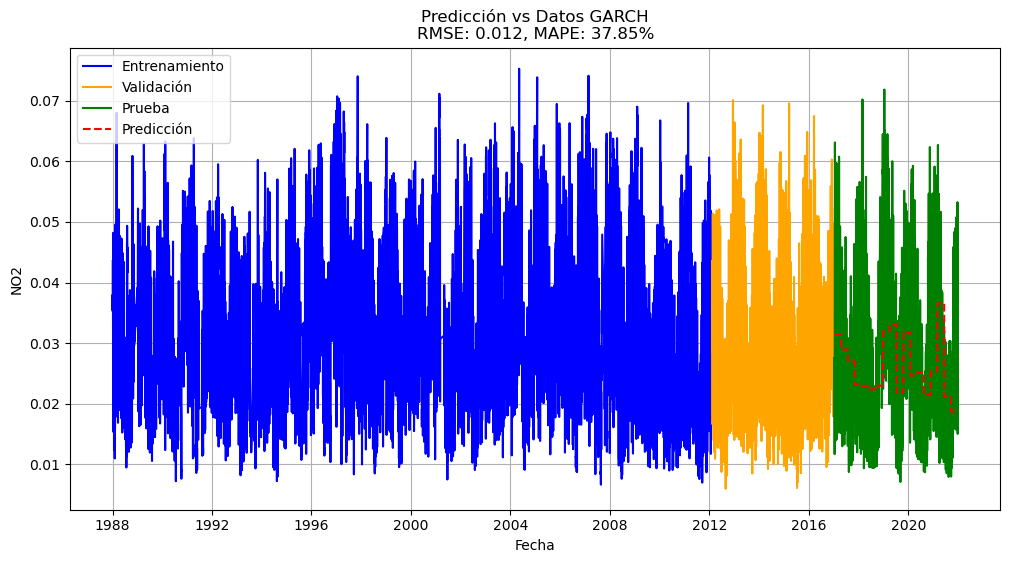

<Figure size 800x400 with 0 Axes>

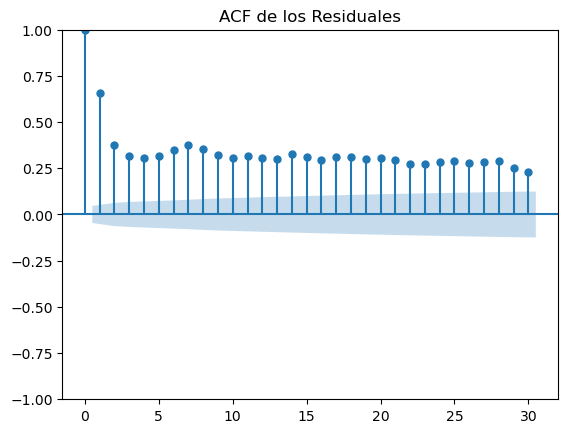

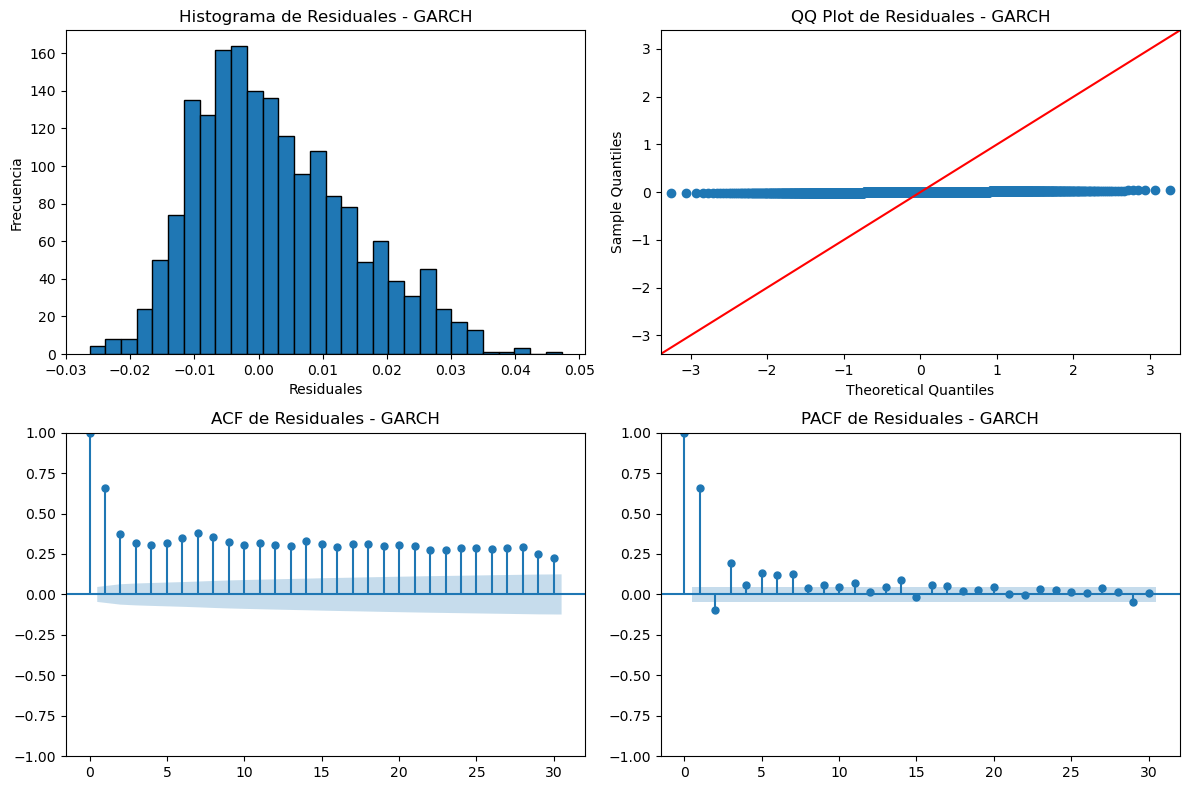

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (mean_squared_error, 
                             mean_absolute_error,
                             mean_absolute_percentage_error)

# Importaciones para análisis de residuales
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
# Prueba de Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

from arch import arch_model

###############################################
# 1) Función para cargar y preprocesar los datos
#    con opción de agregación diaria.
###############################################
def load_and_preprocess_data(csv_path, resample_daily=True):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc = 124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    
    # Convertir a frecuencia horaria y eliminar huecos
    data_hourly = data['no2'].asfreq('H').dropna()
    
    # (OPCIONAL) Agregar a diario para suavizar la serie
    if resample_daily:
        data_resampled = data_hourly.resample('D').mean().dropna()
    else:
        data_resampled = data_hourly

    # División en entrenamiento (70%), validación (15%) y prueba (15%)
    n = len(data_resampled)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_resampled.iloc[:train_size]
    validation = data_resampled.iloc[train_size: train_size + val_size]
    test = data_resampled.iloc[train_size + val_size:]
    
    return train, validation, test

###############################################
# 2) Transformaciones logarítmicas
###############################################
def log_transform(series):
    return np.log1p(series)

def inverse_log_transform(series):
    return np.expm1(series)

###############################################
# 3) Rolling Forecast con AR(1)-GARCH(1,1)
###############################################
def rolling_garch_forecast_log(train_series_log, test_series_log, re_fit_freq=100, window_size=500):
    """
    Realiza un rolling forecast con un modelo AR(1)-GARCH(1,1) en la escala log.
    """
    history_log = train_series_log.copy()
    predictions_log = []
    current_fit = None  
    current_fit_length = None

    for idx, t in tqdm(enumerate(test_series_log.index),
                       total=len(test_series_log), 
                       desc="Rolling GARCH Forecast"):
        if idx % re_fit_freq == 0 or current_fit is None:
            # Ajustar el modelo con la ventana correspondiente
            if len(history_log) > window_size:
                fit_series = history_log[-window_size:]
            else:
                fit_series = history_log
            
            model = arch_model(fit_series, mean='AR', lags=1, 
                               vol='GARCH', p=1, q=1, dist='normal')
            current_fit = model.fit(disp='off')
            current_fit_length = len(fit_series)
        
        # Pronóstico 1 paso
        forecast = current_fit.forecast(horizon=1, start=current_fit_length - 1)
        yhat_log = forecast.mean.iloc[0, 0]
        predictions_log.append(yhat_log)
        
        # Se añade el valor real en log
        real_log_value = test_series_log.loc[t]
        history_log = pd.concat([history_log, pd.Series([real_log_value], index=[t])])
    
    return pd.Series(predictions_log, index=test_series_log.index)

###############################################
# 4) Gráfica de resultados de la serie
###############################################
def plot_results(train, validation, test, predictions, rmse, mape, title="Predicción GARCH"):
    plt.figure(figsize=(12,6))
    plt.plot(train.index, train.values, label="Entrenamiento", color='blue')
    plt.plot(validation.index, validation.values, label="Validación", color='orange')
    plt.plot(test.index, test.values, label="Prueba", color='green')
    plt.plot(predictions.index, predictions.values, '--', label="Predicción", color='red')
    plt.title(f"{title}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%")
    plt.xlabel("Fecha")
    plt.ylabel("NO2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # ACF de residuales
    residuals = test.loc[predictions.index] - predictions
    plt.figure(figsize=(8,4))
    plot_acf(residuals.dropna(), lags=30, alpha=0.05)
    plt.title("ACF de los Residuales")
    plt.show()

###############################################
# 5) Gráfica de análisis de residuales
###############################################
def plot_residual_analysis(residuals, title="GARCH"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Histograma
    axes[0,0].hist(residuals, bins=30, edgecolor='black')
    axes[0,0].set_title(f"Histograma de Residuales - {title}")
    axes[0,0].set_xlabel("Residuales")
    axes[0,0].set_ylabel("Frecuencia")

    # QQ Plot
    qqplot(residuals, line='45', ax=axes[0,1])
    axes[0,1].set_title(f"QQ Plot de Residuales - {title}")

    # ACF
    plot_acf(residuals, lags=30, alpha=0.05, ax=axes[1,0])
    axes[1,0].set_title(f"ACF de Residuales - {title}")

    # PACF
    plot_pacf(residuals, lags=30, alpha=0.05, ax=axes[1,1])
    axes[1,1].set_title(f"PACF de Residuales - {title}")

    plt.tight_layout()
    plt.show()

###############################################
# 6) Función principal
###############################################
def main():
    # Ajusta la ruta a tu CSV
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # Carga y preprocesa (usa resample_daily=False para conservar datos horarios)
    train, validation, test = load_and_preprocess_data(csv_path, resample_daily=True)
    
    # Transformación log
    train_log = log_transform(train)
    val_log   = log_transform(validation)
    test_log  = log_transform(test)
    
    # Unir train + validation
    train_val_log = pd.concat([train_log, val_log])
    
    # Rolling forecast AR-GARCH
    predictions_log = rolling_garch_forecast_log(
        train_val_log, 
        test_log, 
        re_fit_freq=100,    
        window_size=500     
    )
    
    # Invertir log
    predictions = inverse_log_transform(predictions_log)
    
    # Alinear
    test_aligned = test.loc[predictions.index]

    # Métricas
    rmse = np.sqrt(mean_squared_error(test_aligned, predictions))
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    mae  = mean_absolute_error(test_aligned, predictions)
    mse  = mean_squared_error(test_aligned, predictions)
    
    # Prueba de Ljung-Box (ejemplo con lags = [10, 20])
    residuals = test_aligned - predictions
    ljung_results = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)

    # Mostrar métricas y Ljung-Box
    print("\n--- Resultados Rolling GARCH (log-transform) ---")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print("\nPrueba de Ljung-Box:")
    print(ljung_results)
    
    # Graficar
    plot_results(train, validation, test, predictions, rmse, mape, 
                 title="Predicción vs Datos GARCH")
    plot_residual_analysis(residuals.dropna(), title="GARCH")

if __name__ == "__main__":
    main()

<div style="text-align: justify;">

La evaluación del modelo se llevó a cabo mediante métricas de error, obteniendo un RMSE de 0.012, un MAPE del 37.85 %, un MAE de 0.010 y un MSE prácticamente nulo.

El análisis de los residuales incluyó la función de autocorrelación (ACF) y la función de autocorrelación parcial (PACF), herramientas clave para evaluar la independencia de los errores. Dado que los valores de ACF y PACF presentan significancia en ciertos rezagos, esto indica la posible presencia de patrones no capturados por el modelo, sugiriendo que podrían existir efectos persistentes en la serie. Se realizó también la prueba de Ljung-Box con 10 y 20 rezagos, obteniéndose valores p de 0.0 en ambos casos, lo que indica que los residuales no son ruido blanco y aún presentan correlación temporal.

Finalmente, la normalidad de los residuales fue evaluada mediante un gráfico QQ-plot y un histograma. Los residuales no siguen una distribución normal, esto sugiere que el modelo podría beneficiarse de una especificación alternativa o una distribución distinta en el término de error. La interpretación conjunta de estos resultados sugiere que, si bien el modelo captura cierta estructura de la serie, existen indicios de que los residuales presentan autocorrelación y desviaciones de la normalidad, lo que podría motivar ajustes adicionales en la parametrización del modelo.

</div>

# MLP

<div style="text-align: justify;">

Se implementó un modelo de Perceptrón Multicapa (MLP) para predecir la concentración de $NO_2$ en Seúl, utilizando una ventana deslizante de 24 horas como entradas. Se entrenó la red con datos históricos preprocesados, donde se eliminaron valores atípicos extremos, se interpolaron datos faltantes y se estructuraron los datos en un formato supervisado adecuado para el MLP. La arquitectura del modelo incluyó dos capas ocultas densas (20 y 10 neuronas con activación ReLU) y una capa de salida lineal, optimizada con Adam y con función de pérdida MSE.

</div>

C:\Users\MIGUEL HERRERA\AppData\Local\Temp\ipykernel_27160\2509357265.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(series[i+window])
C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando el modelo MLP...
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 4s 455us/step - loss: 5.2023e-05

Realizando predicción en bloque (sin retroalimentar predicciones)...
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 1s 390us/step

Métricas del modelo MLP:
 MSE:  0.000
 RMSE: 0.005
 MAE:  0.004
 MAPE: 16.78%
 Ljung-Box p-value (lag=20): 0.0000


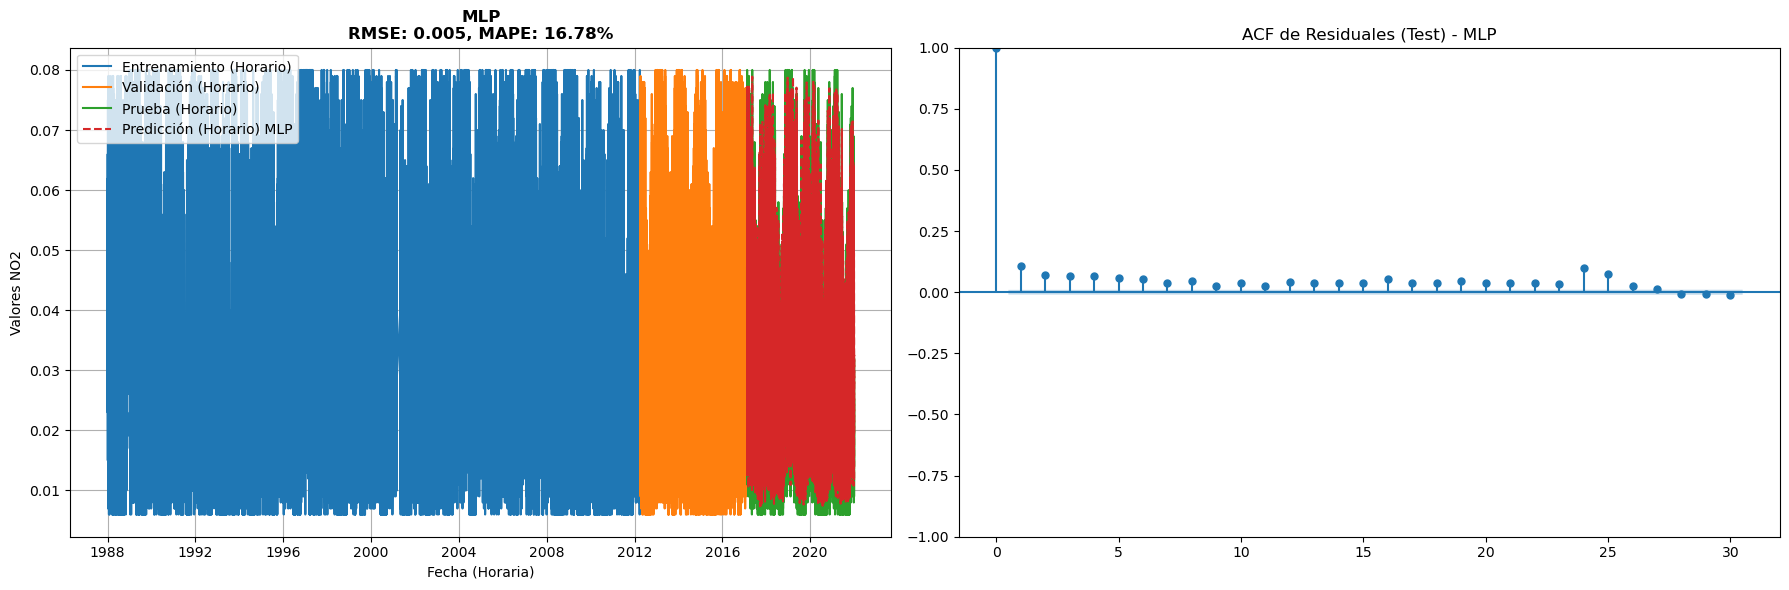

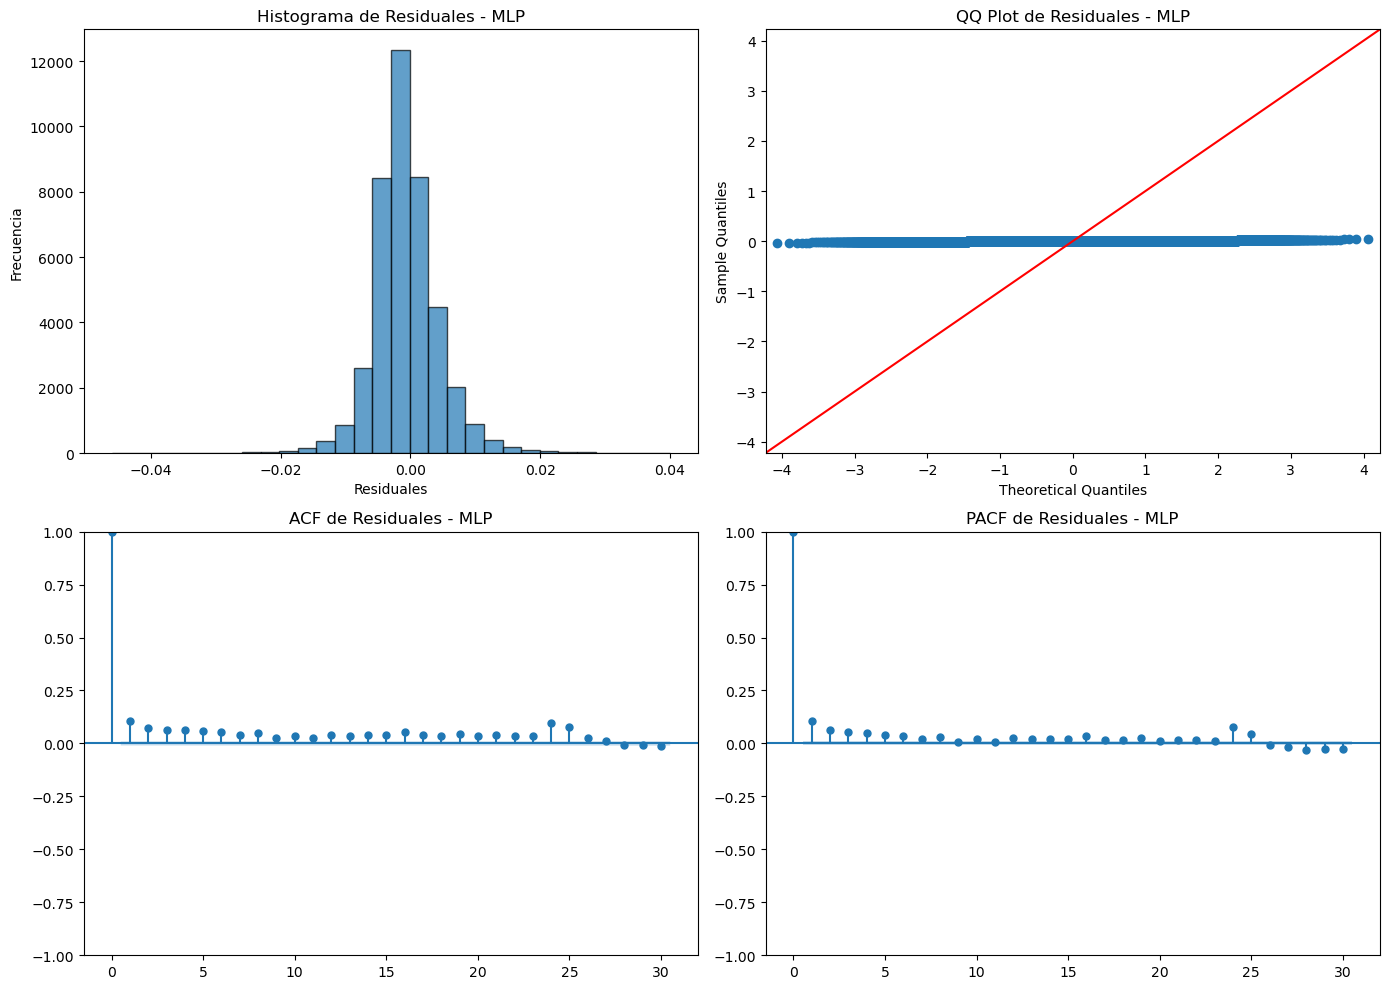

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

##############################################################################
# Función auxiliar para datos supervisados (MLP: entradas 2D)
##############################################################################
def create_supervised_data_mlp(series, window):
    """
    Convierte un array 1D 'series' en un conjunto de datos supervisado,
    con 'window' observaciones pasadas para predecir la siguiente.
    Para el MLP, se mantiene el formato 2D: (muestras, ventana)
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    X = np.array(X)
    y = np.array(y)
    return X, y

##############################################################################
# Carga y preprocesamiento
##############################################################################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc = 124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()

    # División en entrenamiento, validación y prueba
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size: train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##############################################################################
# Aproximación rápida (sin realimentar predicciones) usando MLP
##############################################################################
def fast_sliding_window_forecast_mlp(train_series, test_series, window=24, epochs=3):
    """
    1. Entrena una sola vez con train_series (puede ser train+validation).
    2. Realiza predicción en bloque para todo el conjunto de test.
    """
    # Convertir la serie de entrenamiento a datos supervisados
    X_train, y_train = create_supervised_data_mlp(train_series, window)
    
    # Definir la arquitectura MLP
    model = Sequential()
    model.add(Dense(20, activation='relu', input_shape=(window,)))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    
    # Entrenar el modelo (pocas épocas para rapidez)
    print("Entrenando el modelo MLP...")
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1)
    
    # Preparar los datos de test
    X_test, y_test = create_supervised_data_mlp(test_series.values, window)
    
    # Predicción vectorizada para X_test
    print("\nRealizando predicción en bloque (sin retroalimentar predicciones)...")
    y_pred = model.predict(X_test, verbose=1)
    
    # Alinear las predicciones con las fechas correspondientes
    pred_index = test_series.index[window:]  # Se pierden las primeras 'window' observaciones al crear X_test
    predictions = pd.Series(y_pred.flatten(), index=pred_index)
    
    return predictions

##############################################################################
# Función para graficar resultados y análisis de residuos
##############################################################################
def plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape):
    """
    Grafica series de entrenamiento, validación, test y predicción, junto con el ACF de residuales.
    """
    # FIGURA 1: Predicción vs Datos Reales + ACF de residuales
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    axes[0].plot(train.index, train.values, label="Entrenamiento (Horario)")
    axes[0].plot(validation.index, validation.values, label="Validación (Horario)")
    axes[0].plot(test.index, test.values, label="Prueba (Horario)")
    axes[0].plot(prediction_series.index, prediction_series.values, '--', 
                 label=f"Predicción (Horario) {model_name}")
    
    axes[0].set_title(f"{model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Fecha (Horaria)")
    axes[0].set_ylabel("Valores NO2")
    axes[0].legend()
    axes[0].grid(True)
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF de Residuales (Test) - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # FIGURA 2: Histograma, QQ Plot, ACF y PACF de residuales
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].hist(model_residuals.dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f"Histograma de Residuales - {model_name}")
    axes[0, 0].set_xlabel("Residuales")
    axes[0, 0].set_ylabel("Frecuencia")
    
    sm.qqplot(model_residuals.dropna(), line='45', ax=axes[0, 1])
    axes[0, 1].set_title(f"QQ Plot de Residuales - {model_name}")
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title(f"ACF de Residuales - {model_name}")
    
    plot_pacf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title(f"PACF de Residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##############################################################################
# Función principal
##############################################################################
def main():
    # Cambiar la ruta a tu CSV:
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # Cargar y dividir los datos en train, validación y test
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # Unir train + validación para entrenar el modelo con más datos
    train_val = pd.concat([train, validation])
    
    # Entrenar el MLP y obtener predicciones
    window_size = 24
    epochs = 1
    predictions = fast_sliding_window_forecast_mlp(train_val, test, window=window_size, epochs=epochs)
    
    # Alinear test y predicciones para calcular métricas
    test_aligned = test.loc[predictions.index]
    
    mse = mean_squared_error(test_aligned, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_aligned, predictions)
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    
    # Calcular residuales (observado - predicho)
    model_residuals = test_aligned - predictions
    
    # Prueba de Ljung-Box con 20 rezagos
    lb_test = acorr_ljungbox(model_residuals.dropna(), lags=[20], return_df=True)
    ljung_box_pvalue = lb_test['lb_pvalue'].values[0]
    
    print("\nMétricas del modelo MLP:")
    print(f" MSE:  {mse:.3f}")
    print(f" RMSE: {rmse:.3f}")
    print(f" MAE:  {mae:.3f}")
    print(f" MAPE: {mape:.2f}%")
    print(f" Ljung-Box p-value (lag=20): {ljung_box_pvalue:.4f}")
    
    # Graficar resultados y análisis de residuales
    plot_model_results(
        train=train, 
        validation=validation, 
        test=test, 
        prediction_series=predictions, 
        model_residuals=model_residuals, 
        model_name="MLP", 
        rmse=rmse, 
        mape=mape
    )

if __name__ == "__main__":
    main()

<div style="text-align: justify;">

Los resultados mostraron un RMSE de 0.005, un MAE de 0.004 y un MAPE del 16.78%, indicando que el modelo tiene un desempeño razonable, aunque con margen de mejora. Sin embargo, el análisis de residuos reveló que estos aún presentan autocorrelación significativa, con un p-value de 0.0000 en la prueba de Ljung-Box (lag=20), lo que sugiere que el modelo no captura completamente la estructura temporal de los datos. Esto implica que las predicciones pueden verse afectadas por patrones no modelados, y una posible mejora sería considerar modelos con retroalimentación o enfoques más especializados para series temporales.

</div>

# RNN

<div style="text-align: justify;">

Se desarrolló un modelo basado en redes neuronales recurrentes (RNN) con una arquitectura simple utilizando SimpleRNN para predecir los niveles horarios de $NO_2$ en Seúl. La metodología empleada incluyó una transformación de los datos en un formato supervisado mediante una estrategia de sliding window con una ventana de 24 horas, lo que permitió a la RNN aprender patrones temporales en la serie. Los datos fueron preprocesados eliminando valores atípicos, interpolando valores faltantes y estructurando la serie en tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%). Posteriormente, el modelo fue entrenado con los datos combinados de entrenamiento y validación, y se realizó una predicción en bloque sobre la serie de prueba sin realimentación de predicciones previas.

</div>

C:\Users\MIGUEL HERRERA\AppData\Local\Temp\ipykernel_27160\2947959178.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(series[i+window])
C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando el modelo RNN...
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 4.6794e-05

Realizando predicción en bloque (sin retroalimentación de predicciones)...
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step

Métricas del modelo RNN:
 MSE:  0.000
 RMSE: 0.005
 MAE:  0.004
 MAPE: 16.67%
 Ljung-Box p-value (lag=20): 0.0000


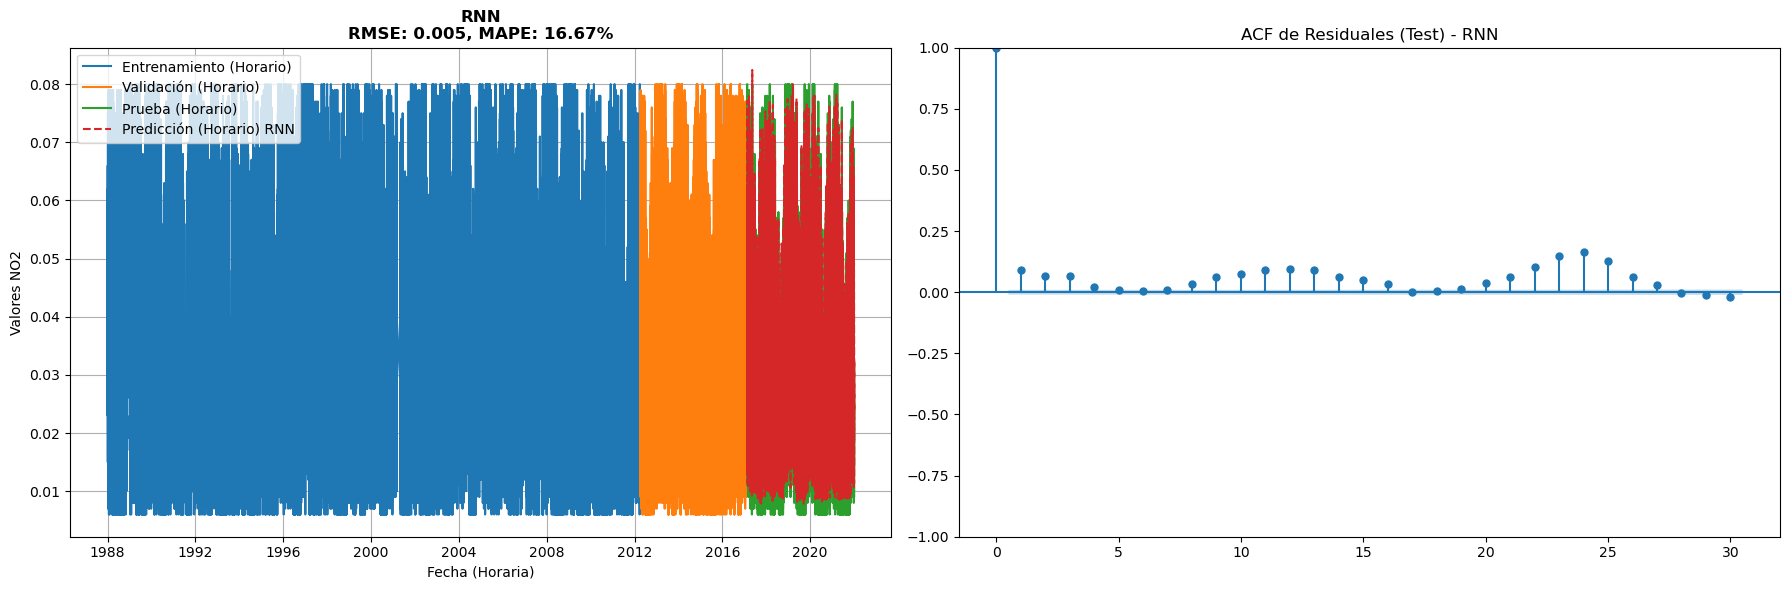

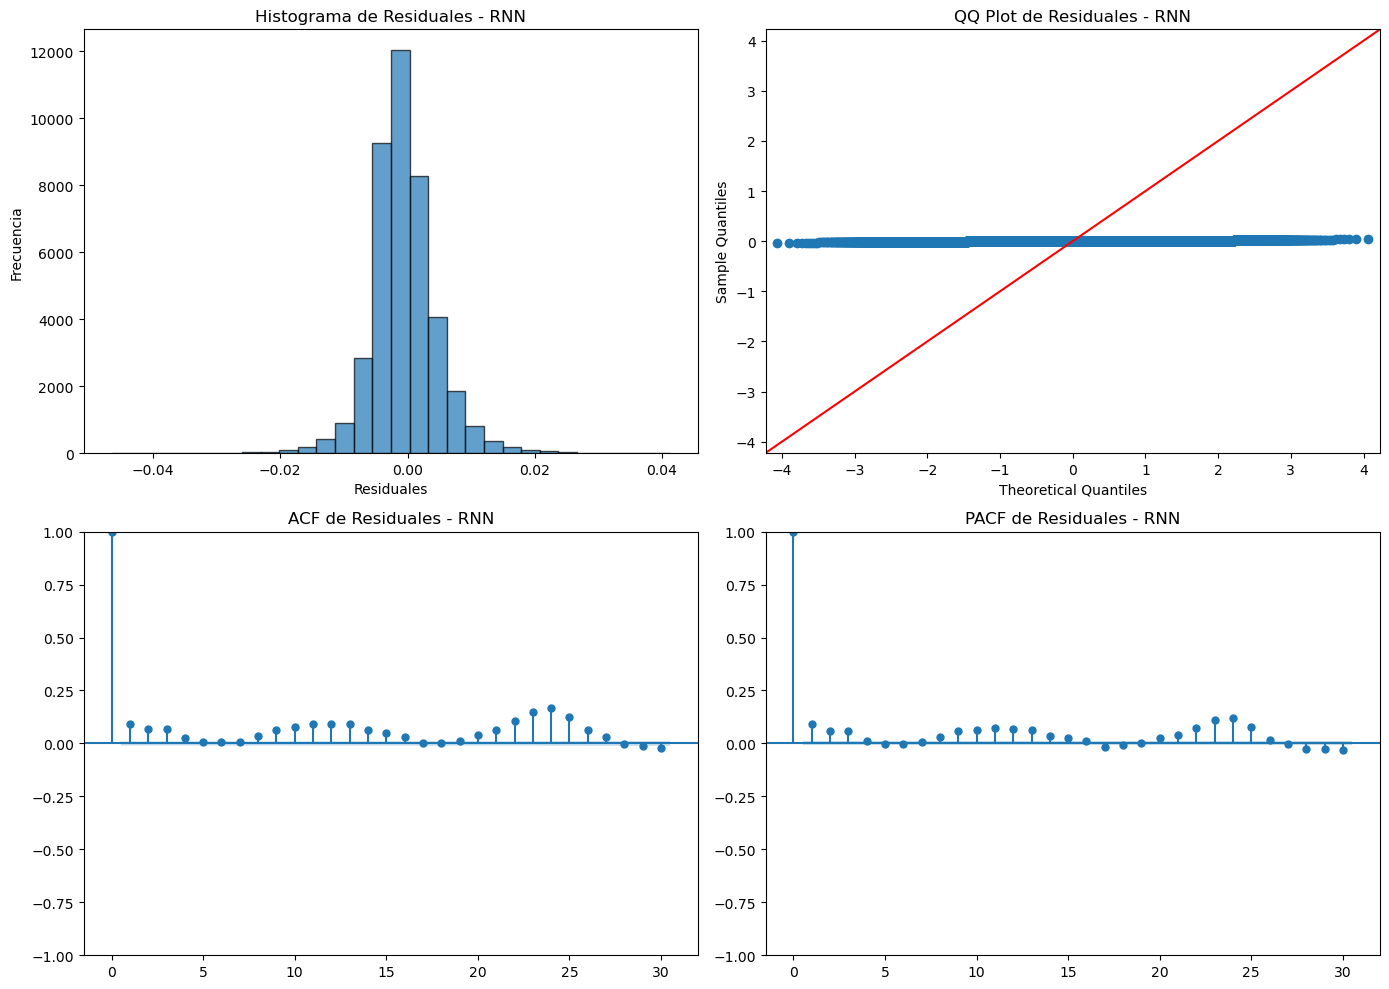

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

##############################################################################
# Función auxiliar para datos supervisados
##############################################################################
def create_supervised_data(series, window):
    """
    Convierte un array 1D 'series' en un conjunto de datos supervisado,
    con 'window' observaciones pasadas para predecir la siguiente.
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    X = np.array(X)
    y = np.array(y)
    # Reestructurar para RNN: (muestras, pasos de tiempo, features=1)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

##############################################################################
# Carga y preprocesamiento
##############################################################################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc = 124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()

    # División en entrenamiento, validación y prueba
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size: train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##############################################################################
# Aproximación rápida (sin realimentar predicciones) usando RNN
##############################################################################
def fast_sliding_window_forecast(train_series, test_series, window=24, epochs=3):
    """
    1. Entrena una sola vez con train_series (puede ser train+validation).
    2. Realiza una predicción en bloque para todo test usando la arquitectura RNN.
    """
    # Convertir la serie de entrenamiento a datos supervisados
    X_train, y_train = create_supervised_data(train_series, window)
    
    # Definir la arquitectura RNN con SimpleRNN
    model = Sequential()
    model.add(SimpleRNN(10, activation='relu', input_shape=(window, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    
    # Entrenar el modelo
    print("Entrenando el modelo RNN...")
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1)
    
    # Preparar datos para el test
    X_test, y_test = create_supervised_data(test_series.values, window)
    
    # Predicción vectorizada de todo X_test
    print("\nRealizando predicción en bloque (sin retroalimentación de predicciones)...")
    y_pred = model.predict(X_test, verbose=1)
    
    # Alinear el vector de predicciones con las fechas correspondientes
    pred_index = test_series.index[window:]  # se pierden las primeras 'window' observaciones al crear X_test
    predictions = pd.Series(y_pred.flatten(), index=pred_index)
    
    return predictions

##############################################################################
# Función para graficar resultados y análisis de residuos
##############################################################################
def plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape):
    """
    Grafica las series de entrenamiento, validación, test y las predicciones.
    Además, se muestra la ACF de los residuales y un análisis gráfico adicional.
    """
    # FIGURA 1: Predicción vs Datos Reales + ACF de residuales
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    axes[0].plot(train.index, train.values, label="Entrenamiento (Horario)")
    axes[0].plot(validation.index, validation.values, label="Validación (Horario)")
    axes[0].plot(test.index, test.values, label="Prueba (Horario)")
    axes[0].plot(prediction_series.index, prediction_series.values, '--', 
                 label=f"Predicción (Horario) {model_name}")
    
    axes[0].set_title(f"{model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Fecha (Horaria)")
    axes[0].set_ylabel("Valores NO2")
    axes[0].legend()
    axes[0].grid(True)
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF de Residuales (Test) - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # FIGURA 2: Histograma, QQ Plot, ACF y PACF de los residuales
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].hist(model_residuals.dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f"Histograma de Residuales - {model_name}")
    axes[0, 0].set_xlabel("Residuales")
    axes[0, 0].set_ylabel("Frecuencia")
    
    sm.qqplot(model_residuals.dropna(), line='45', ax=axes[0, 1])
    axes[0, 1].set_title(f"QQ Plot de Residuales - {model_name}")
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title(f"ACF de Residuales - {model_name}")
    
    plot_pacf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title(f"PACF de Residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##############################################################################
# Función principal
##############################################################################
def main():
    # Cambiar la ruta a tu CSV
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # Cargar y dividir los datos en train, validation y test
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # Unir train + validation para entrenar el modelo con más datos
    train_val = pd.concat([train, validation])
    
    # Entrenar la RNN y obtener predicciones
    window_size = 24
    epochs = 1
    predictions = fast_sliding_window_forecast(train_val, test, window=window_size, epochs=epochs)
    
    # Alinear test y predicciones para calcular métricas
    test_aligned = test.loc[predictions.index]
    
    mse = mean_squared_error(test_aligned, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_aligned, predictions)
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    
    # Calcular residuales (observado - predicho)
    model_residuals = test_aligned - predictions
    
    # Prueba de Ljung-Box con 20 rezagos
    lb_test = acorr_ljungbox(model_residuals.dropna(), lags=[20], return_df=True)
    ljung_box_pvalue = lb_test['lb_pvalue'].values[0]
    
    print("\nMétricas del modelo RNN:")
    print(f" MSE:  {mse:.3f}")
    print(f" RMSE: {rmse:.3f}")
    print(f" MAE:  {mae:.3f}")
    print(f" MAPE: {mape:.2f}%")
    print(f" Ljung-Box p-value (lag=20): {ljung_box_pvalue:.4f}")
    
    # Graficar resultados y análisis de residuales
    plot_model_results(
        train=train, 
        validation=validation, 
        test=test, 
        prediction_series=predictions, 
        model_residuals=model_residuals, 
        model_name="RNN", 
        rmse=rmse, 
        mape=mape
    )

if __name__ == "__main__":
    main()


<div style="text-align: justify;">

Los resultados del modelo muestran que el error cuadrático medio (MSE) es prácticamente nulo, con un RMSE de 0.005, lo que sugiere una baja magnitud de error absoluto en términos de la escala de los datos. Sin embargo, el MAPE (Mean Absolute Percentage Error) se reporta en 16.67%, lo que indica que, en promedio, las predicciones difieren en un 16.67% del valor real, lo cual es un porcentaje considerablemente alto. Además, el análisis de los residuales mediante la prueba de Ljung-Box revela que el p-valor para 20 rezagos es menor a 0.05 $(p \simeq 0.0000)$, lo que sugiere que los residuos no son independientes y presentan autocorrelación significativa. Esto se confirma al analizar la ACF y PACF de los residuales, donde se observan correlaciones persistentes en varios rezagos, lo que indica que el modelo no ha capturado completamente la estructura temporal de los datos. Adicionalmente, el análisis gráfico de los residuales, incluyendo el histograma y el QQ-plot, evidencia desviaciones respecto a la normalidad, lo que implica que los errores no siguen una distribución normal y podrían contener estructuras no modeladas. Estos hallazgos sugieren que, si bien la RNN logra ajustarse a los datos en términos de minimización del error cuadrático, su capacidad de generalización puede ser limitada y requiere ajustes adicionales, como técnicas más avanzadas de modelado de series temporales o la incorporación de mecanismos de memoria más largos como LSTMs.

</div>

# LSTM

<div style="text-align: justify;">

Se desarrolló un modelo basado en redes neuronales de memoria a corto y largo plazo (LSTM) para predecir los niveles horarios de $NO_2$ en la ubicación 124. La metodología empleada incluyó la transformación de los datos en un formato supervisado mediante una estrategia de sliding window, lo que permitió a la LSTM capturar dependencias temporales en la serie. Los datos fueron preprocesados eliminando valores atípicos, interpolando valores faltantes y estructurando la serie en tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%). Posteriormente, el modelo fue entrenado con los datos combinados de entrenamiento y validación, y se realizó una predicción en bloque sobre la serie de prueba sin realimentación de predicciones previas.

</div>

C:\Users\MIGUEL HERRERA\AppData\Local\Temp\ipykernel_27160\3249985603.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(series[i+window])
C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando el modelo LSTM...
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - loss: 9.3760e-05

Realizando predicción en bloque (sin retroalimentación)...
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Métricas del modelo LSTM:
 MSE:  0.000
 RMSE: 0.005
 MAE:  0.004
 MAPE: 16.03%
 Ljung-Box p-value (lag=20): 0.0000


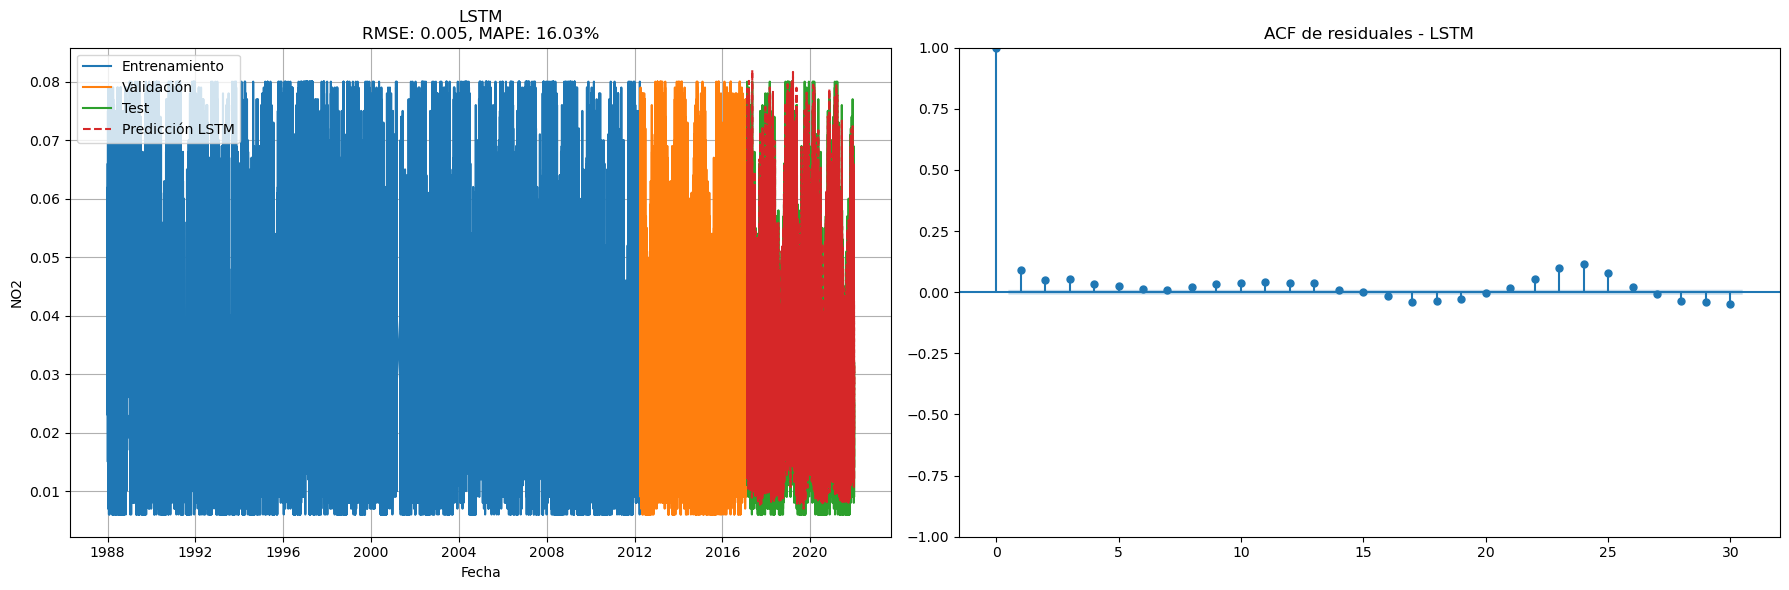

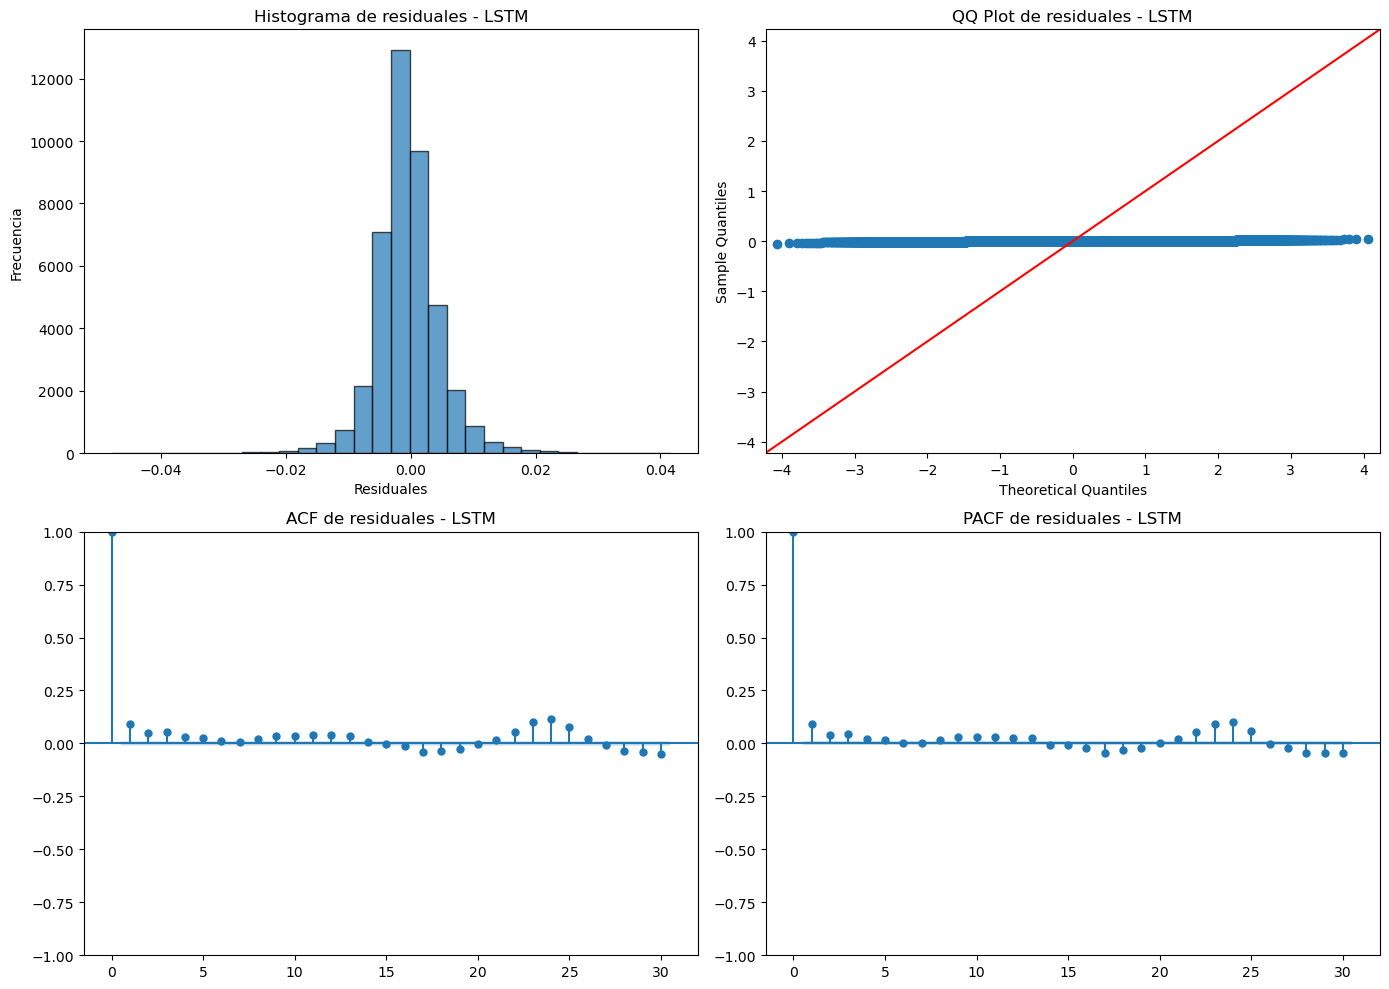

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

##############################################################################
# Función auxiliar para crear datos supervisados
##############################################################################
def create_supervised_data(series, window):
    """
    Convierte un array 1D 'series' en un conjunto de datos supervisado,
    usando 'window' observaciones pasadas para predecir la siguiente.
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    X = np.array(X)
    y = np.array(y)
    # Reestructurar para LSTM: (muestras, pasos de tiempo, features=1)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

##############################################################################
# Carga y preprocesamiento
##############################################################################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc = 124
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()

    # División en entrenamiento, validación y test
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size: train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##############################################################################
# Aproximación rápida con LSTM
##############################################################################
def fast_sliding_window_forecast(train_series, test_series, window=24, epochs=3):
    """
    1. Entrena una única vez con train_series (puede ser train+validation).
    2. Realiza predicción en bloque sobre el conjunto de test.
    """
    # Preparar datos supervisados para entrenamiento
    X_train, y_train = create_supervised_data(train_series, window)
    
    # Definir la arquitectura LSTM
    model = Sequential()
    model.add(LSTM(10, activation='relu', input_shape=(window, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    
    # Entrenar el modelo
    print("Entrenando el modelo LSTM...")
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1)
    
    # Preparar datos supervisados para test
    X_test, _ = create_supervised_data(test_series.values, window)
    
    # Predicción en bloque
    print("\nRealizando predicción en bloque (sin retroalimentación)...")
    y_pred = model.predict(X_test, verbose=1)
    
    # Alinear predicciones con las fechas correspondientes
    pred_index = test_series.index[window:]
    predictions = pd.Series(y_pred.flatten(), index=pred_index)
    
    return predictions

##############################################################################
# Función para graficar resultados y análisis de residuales
##############################################################################
def plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape):
    # FIGURA 1: Datos y predicción + ACF de residuales
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    axes[0].plot(train.index, train.values, label="Entrenamiento")
    axes[0].plot(validation.index, validation.values, label="Validación")
    axes[0].plot(test.index, test.values, label="Test")
    axes[0].plot(prediction_series.index, prediction_series.values, '--', 
                 label=f"Predicción {model_name}")
    axes[0].set_title(f"{model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("NO2")
    axes[0].legend()
    axes[0].grid(True)
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF de residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # FIGURA 2: Análisis gráfico de residuales
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].hist(model_residuals.dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f"Histograma de residuales - {model_name}")
    axes[0, 0].set_xlabel("Residuales")
    axes[0, 0].set_ylabel("Frecuencia")
    
    sm.qqplot(model_residuals.dropna(), line='45', ax=axes[0, 1])
    axes[0, 1].set_title(f"QQ Plot de residuales - {model_name}")
    
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title(f"ACF de residuales - {model_name}")
    
    plot_pacf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title(f"PACF de residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##############################################################################
# Función principal
##############################################################################
def main():
    # Ruta a tu CSV
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # Cargar y dividir datos
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # Combinar train y validación para mayor cantidad de datos de entrenamiento
    train_val = pd.concat([train, validation])
    
    # Entrenar LSTM y obtener predicciones
    window_size = 24
    epochs = 1
    predictions = fast_sliding_window_forecast(train_val, test, window=window_size, epochs=epochs)
    
    # Alinear test y predicciones para evaluación
    test_aligned = test.loc[predictions.index]
    mse = mean_squared_error(test_aligned, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_aligned, predictions)
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    
    # Calcular residuales (observado - predicho)
    model_residuals = test_aligned - predictions
    
    # Prueba de Ljung-Box (20 rezagos)
    lb_test = acorr_ljungbox(model_residuals.dropna(), lags=[20], return_df=True)
    ljung_box_pvalue = lb_test['lb_pvalue'].values[0]
    
    print("\nMétricas del modelo LSTM:")
    print(f" MSE:  {mse:.3f}")
    print(f" RMSE: {rmse:.3f}")
    print(f" MAE:  {mae:.3f}")
    print(f" MAPE: {mape:.2f}%")
    print(f" Ljung-Box p-value (lag=20): {ljung_box_pvalue:.4f}")
    
    # Graficar resultados y análisis de residuales
    plot_model_results(
        train=train, 
        validation=validation, 
        test=test, 
        prediction_series=predictions, 
        model_residuals=model_residuals, 
        model_name="LSTM", 
        rmse=rmse, 
        mape=mape
    )

if __name__ == "__main__":
    main()


In [16]:
#!pip install keras-tcn

<div style="text-align: justify;">

Los resultados del modelo muestran un error cuadrático medio (MSE) cercano a cero, con un RMSE de 0.005, lo que indica una baja magnitud de error absoluto en relación con la escala de los datos. Sin embargo, el MAPE (Mean Absolute Percentage Error) es de 16.03%, lo que sugiere que, en promedio, las predicciones difieren en un 16.03% del valor real. El análisis de los residuales mediante la prueba de Ljung-Box revela que el p-valor para 20 rezagos es menor a 0.05 $(p \simeq 0.0000)$, lo que indica autocorrelación significativa en los errores. La ACF y PACF de los residuales confirman la presencia de correlaciones persistentes, lo que sugiere que el modelo no ha capturado completamente la estructura temporal de los datos. Adicionalmente, el análisis gráfico de los residuales, incluyendo el histograma y el QQ-plot, muestra desviaciones respecto a la normalidad, lo que implica que los errores no siguen una distribución normal y podrían contener patrones no modelados. Estos resultados sugieren que, aunque la LSTM logra minimizar el error cuadrático, su capacidad de generalización podría ser mejorada mediante ajustes adicionales, como una mayor profundidad en la arquitectura, técnicas de regularización o el uso de modelos híbridos que incorporen otros enfoques de modelado de series temporales.

</div>

# TCN

<div style="text-align: justify;">

Se desarrolló un modelo basado en redes neuronales convolucionales temporales (TCN) para predecir los niveles horarios de $NO_2$ en Seúl. La metodología empleada incluyó la conversión de la serie temporal en un formato supervisado mediante una ventana deslizante de 24 horas, permitiendo que la TCN capture patrones temporales en los datos. Los datos fueron preprocesados eliminando valores atípicos, interpolando valores faltantes y dividiendo la serie en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Posteriormente, el modelo fue entrenado con los datos combinados de entrenamiento y validación utilizando 5 épocas con early stopping, y la predicción se realizó en bloque sobre la serie de prueba sin realimentación de predicciones previas.

</div>

Entrenando el modelo TCN (una vez) con epochs = 5
Epoch 1/5
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - loss: 5.5005e-04 - learning_rate: 0.0010
Epoch 2/5
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 4.2027e-05 - learning_rate: 0.0010
Epoch 3/5
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step - loss: 4.0710e-05 - learning_rate: 0.0010
Epoch 4/5
7352/7357 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.0266e-05
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step - loss: 4.0266e-05 - learning_rate: 0.0010
Epoch 5/5
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - loss: 3.8998e-05 - learning_rate: 5.0000e-04

Realizando predicción en bloque sobre el set de test...
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

=== TCN con entrenamiento en épocas ===
MSE:  0.000
RMSE: 0.005
MAE:  0.004
MAPE: 14.33%
Ljung-Box p-value (lag=20): 0.0000


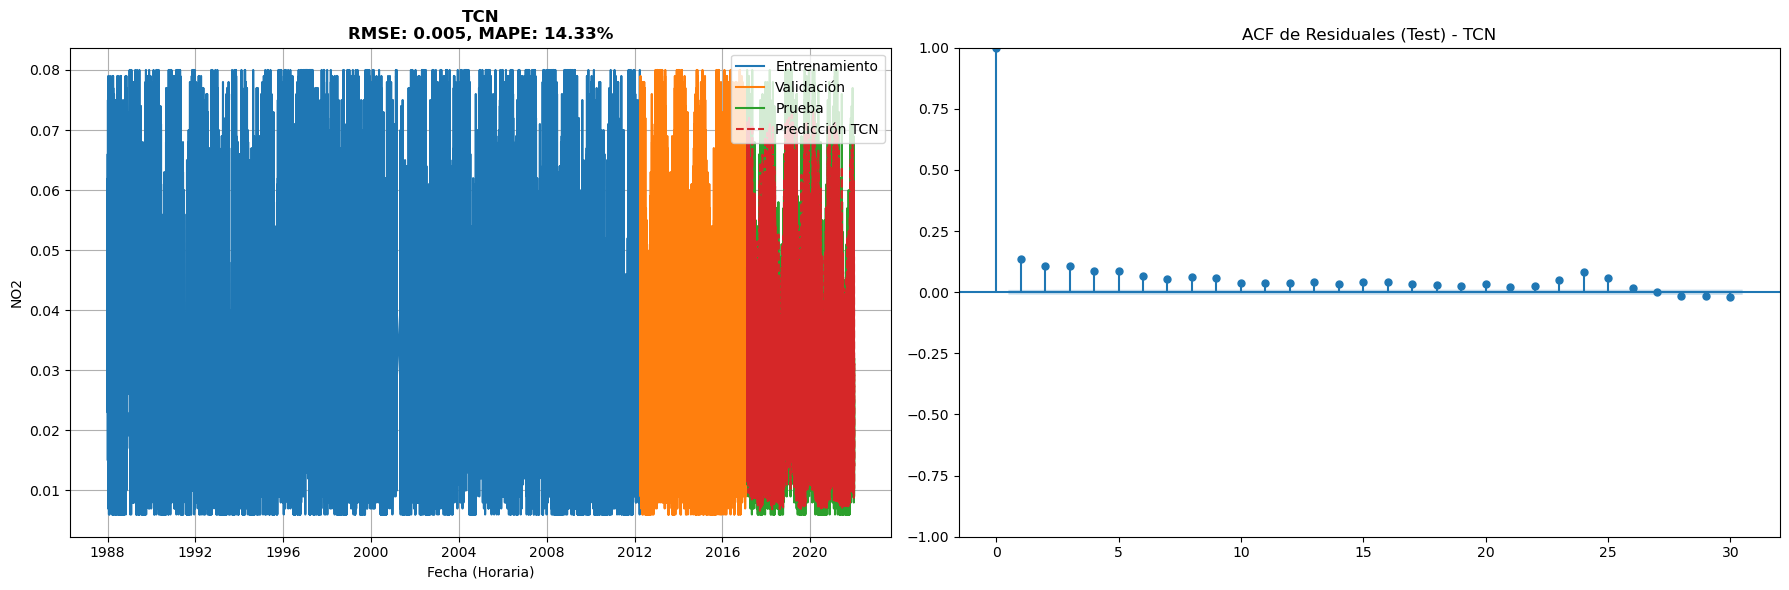

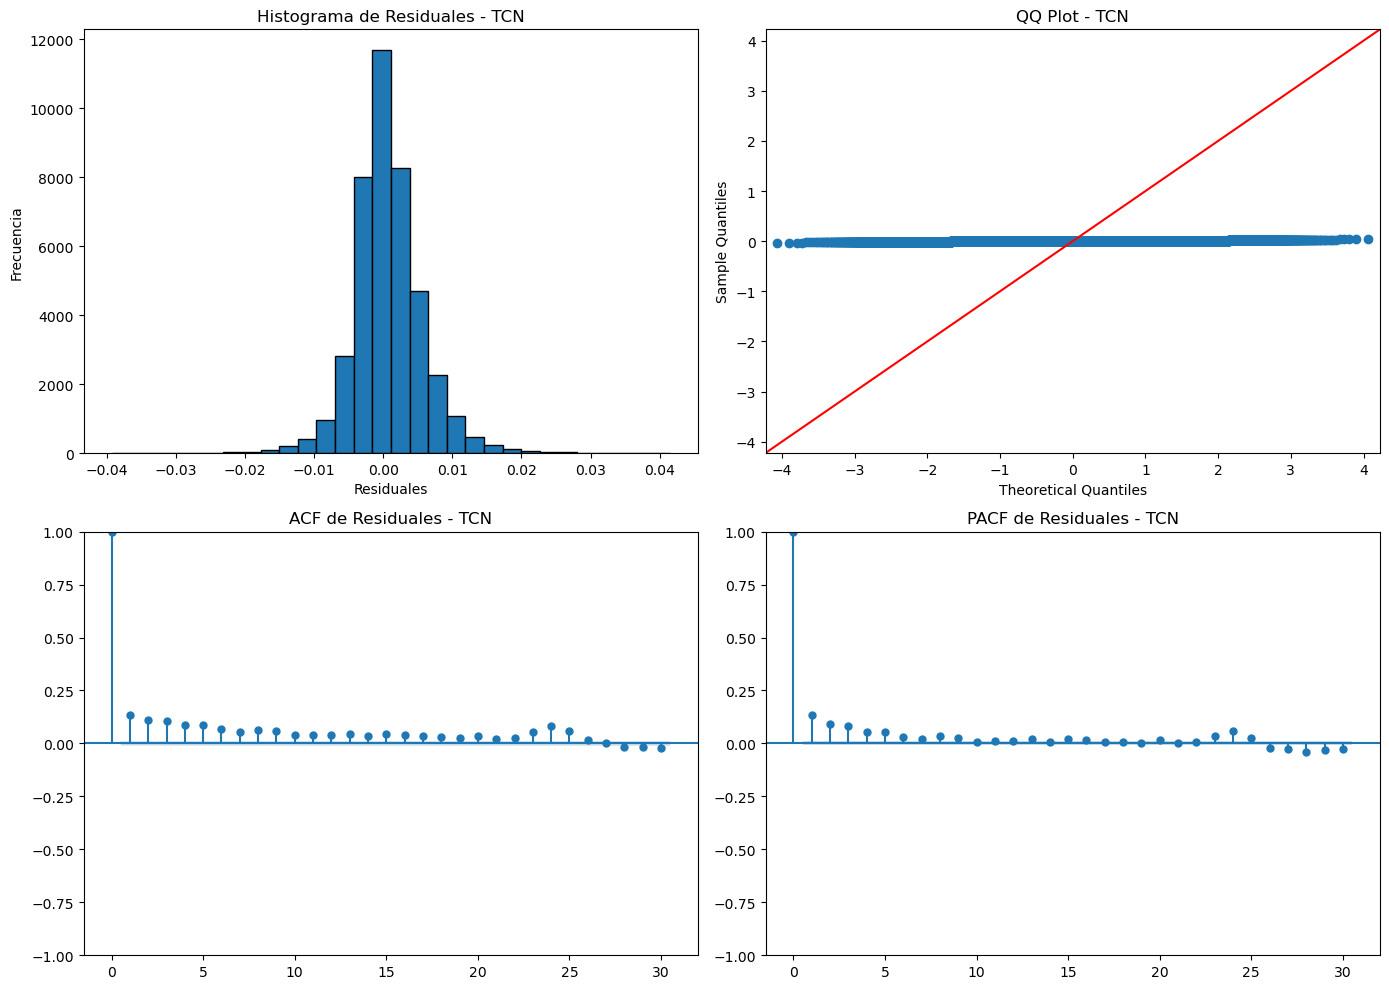

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Instala keras-tcn: pip install keras-tcn
from tcn import TCN

##############################################################################
# 1) Crear datos supervisados (ventana)
##############################################################################
def create_supervised_data(series, window):
    """
    Dada una serie 1D, crea X (con shape (muestras, window, 1)) e y (shape (muestras,))
    usando una ventana deslizante para predecir el siguiente valor.
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i: i + window])
        y.append(series[i + window])
    X = np.array(X)
    y = np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

##############################################################################
# 2) Carga y preprocesamiento de datos
##############################################################################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]
    
    # Filtrar para loc=124
    data = data[data['loc'] == 124].drop(columns=['loc'])
    
    # Eliminar outliers (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]
    
    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')
    
    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()
    
    # Dividir en 70% train, 15% validation y 15% test
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    
    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size: train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##############################################################################
# 3) Entrenamiento TCN con Épocas (sin rolling) y predicción en bloque
##############################################################################
def train_tcn_forecast(train_series, test_series, 
                       window=24, 
                       epochs=50,
                       nb_filters=64, 
                       kernel_size=3, 
                       nb_stacks=1, 
                       dilations=[1,2,4,8],
                       dropout_rate=0.2, 
                       random_state=42):
    """
    Entrena una TCN (usando train_series combinada) y realiza la predicción en bloque 
    sobre test_series usando una ventana de 'window' pasos.
    """
    tf.random.set_seed(random_state)
    np.random.seed(random_state)
    
    # Convertir la serie de entrenamiento a array y generar datos supervisados
    train_arr = train_series.values
    X_train, y_train = create_supervised_data(train_arr, window)
    
    # Definir el modelo TCN
    inputs = tf.keras.Input(shape=(window, 1))
    x = TCN(nb_filters=nb_filters,
            kernel_size=kernel_size,
            nb_stacks=nb_stacks,
            dilations=dilations,
            padding='causal',
            use_skip_connections=True,
            dropout_rate=dropout_rate,
            return_sequences=False,
            activation='relu')(inputs)
    outputs = tf.keras.layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(optimizer='adam', loss='mse')
    
    # Callbacks para acelerar la convergencia
    early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)
    
    print("Entrenando el modelo TCN (una vez) con epochs =", epochs)
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1, callbacks=[early_stop, reduce_lr])
    
    # Preparar datos de test para predicción (crea X_test vectorizado)
    test_arr = test_series.values
    X_test, y_test = create_supervised_data(test_arr, window)
    
    print("\nRealizando predicción en bloque sobre el set de test...")
    y_pred = model.predict(X_test, verbose=1)
    
    # Alinear índice: se pierden las primeras 'window' observaciones en test
    pred_index = test_series.index[window:]
    predictions = pd.Series(y_pred.flatten(), index=pred_index)
    return predictions, y_test

##############################################################################
# 4) Función para graficar resultados y análisis de residuales (6 gráficas)
##############################################################################
def plot_model_results(train, validation, test, predictions, residuals, model_name, rmse, mape):
    # Figura 1: Predicción vs Datos Reales + ACF de residuales
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    axes[0].plot(train.index, train.values, label="Entrenamiento")
    axes[0].plot(validation.index, validation.values, label="Validación")
    axes[0].plot(test.index, test.values, label="Prueba")
    axes[0].plot(predictions.index, predictions.values, '--', label=f"Predicción {model_name}")
    axes[0].set_title(f"{model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Fecha (Horaria)")
    axes[0].set_ylabel("NO2")
    axes[0].legend()
    axes[0].grid(True)
    
    plot_acf(residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF de Residuales (Test) - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # Figura 2: Análisis de residuales (Histograma, QQ Plot, ACF, PACF)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0,0].hist(residuals.dropna(), bins=30, edgecolor='black')
    axes[0,0].set_title(f"Histograma de Residuales - {model_name}")
    axes[0,0].set_xlabel("Residuales")
    axes[0,0].set_ylabel("Frecuencia")
    
    sm.qqplot(residuals.dropna(), line='45', ax=axes[0,1])
    axes[0,1].set_title(f"QQ Plot - {model_name}")
    
    plot_acf(residuals.dropna(), lags=30, alpha=0.05, ax=axes[1,0])
    axes[1,0].set_title(f"ACF de Residuales - {model_name}")
    
    plot_pacf(residuals.dropna(), lags=30, alpha=0.05, ax=axes[1,1])
    axes[1,1].set_title(f"PACF de Residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##############################################################################
# 5) Función principal
##############################################################################
def main():
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # Unir train + validation para entrenar un solo modelo
    train_val = pd.concat([train, validation])
    
    # Entrenar la TCN con epochs (por ejemplo, 50) de forma rápida (con early stopping)
    window_size = 24  # 24 horas de ventana
    predictions, y_test = train_tcn_forecast(train_series=train_val, test_series=test,
                                              window=window_size, epochs=5,
                                              nb_filters=64, kernel_size=3, nb_stacks=1,
                                              dilations=[1,2,4,8], dropout_rate=0.2,
                                              random_state=42)
    
    # Alinear test para métricas (se pierden las primeras 'window_size' observaciones)
    test_aligned = test.loc[predictions.index]
    mse = mean_squared_error(test_aligned, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(test_aligned, predictions)
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    
    # Calcular residuales y aplicar la prueba de Ljung-Box (lag=20)
    residuals = test_aligned - predictions
    lb_test = acorr_ljungbox(residuals.dropna(), lags=[20], return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].values[0]
    
    print("\n=== TCN con entrenamiento en épocas ===")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Ljung-Box p-value (lag=20): {lb_pvalue:.4f}")
    
    # Graficar resultados y análisis de residuales
    plot_model_results(train, validation, test, predictions, residuals,
                       model_name="TCN", rmse=rmse, mape=mape)

if __name__ == "__main__":
    main()

Entrenando el modelo TCN...
Epoch 1/3


C:\Users\MIGUEL HERRERA\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7357/7357 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 6.3176e-05
Epoch 2/3
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 4.0456e-05
Epoch 3/3
7357/7357 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 3.9781e-05

Realizando predicción en bloque (sin retroalimentar predicciones)...
1298/1298 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step

=== Métricas del modelo TCN ===
 MSE :  0.000
 RMSE:  0.005
 MAE :  0.004
 MAPE:  18.47%
 Ljung-Box p-value (lag=20): 0.0000


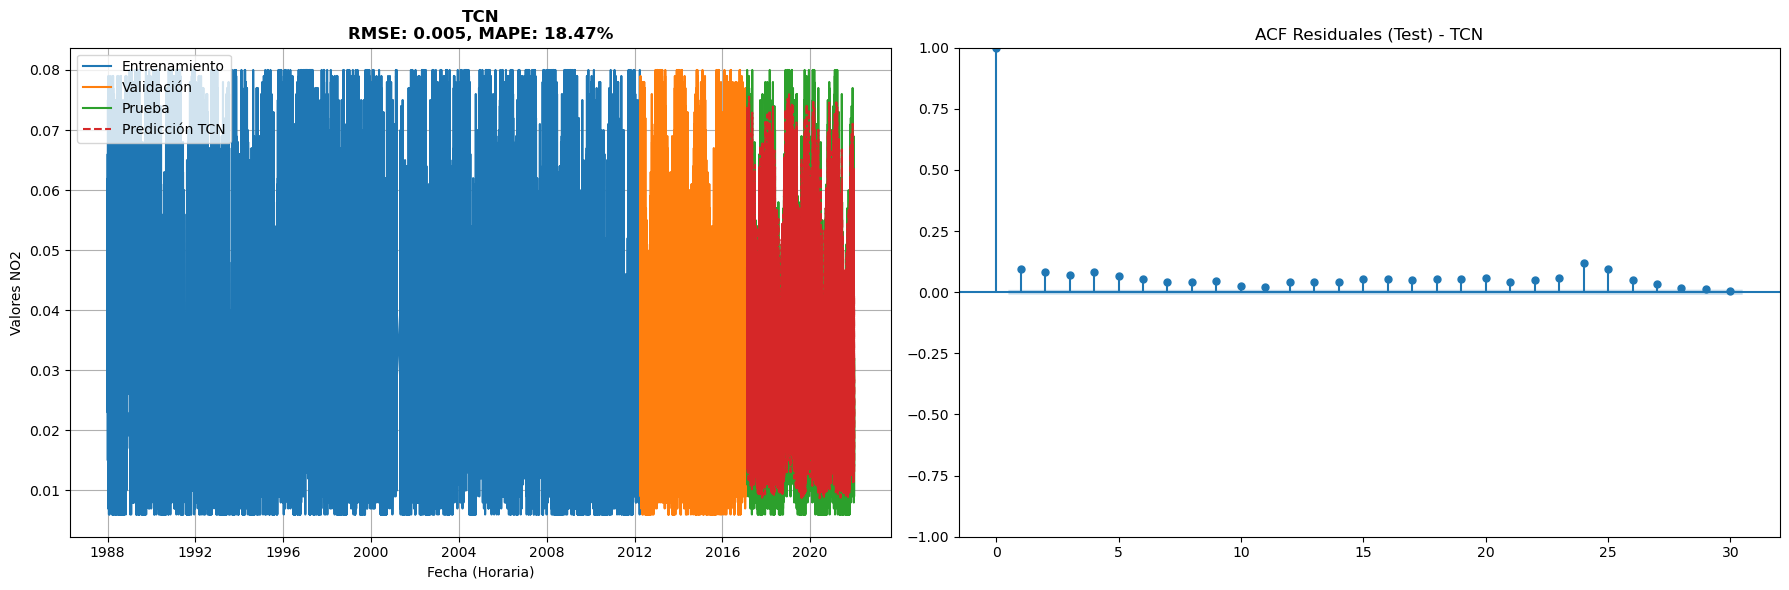

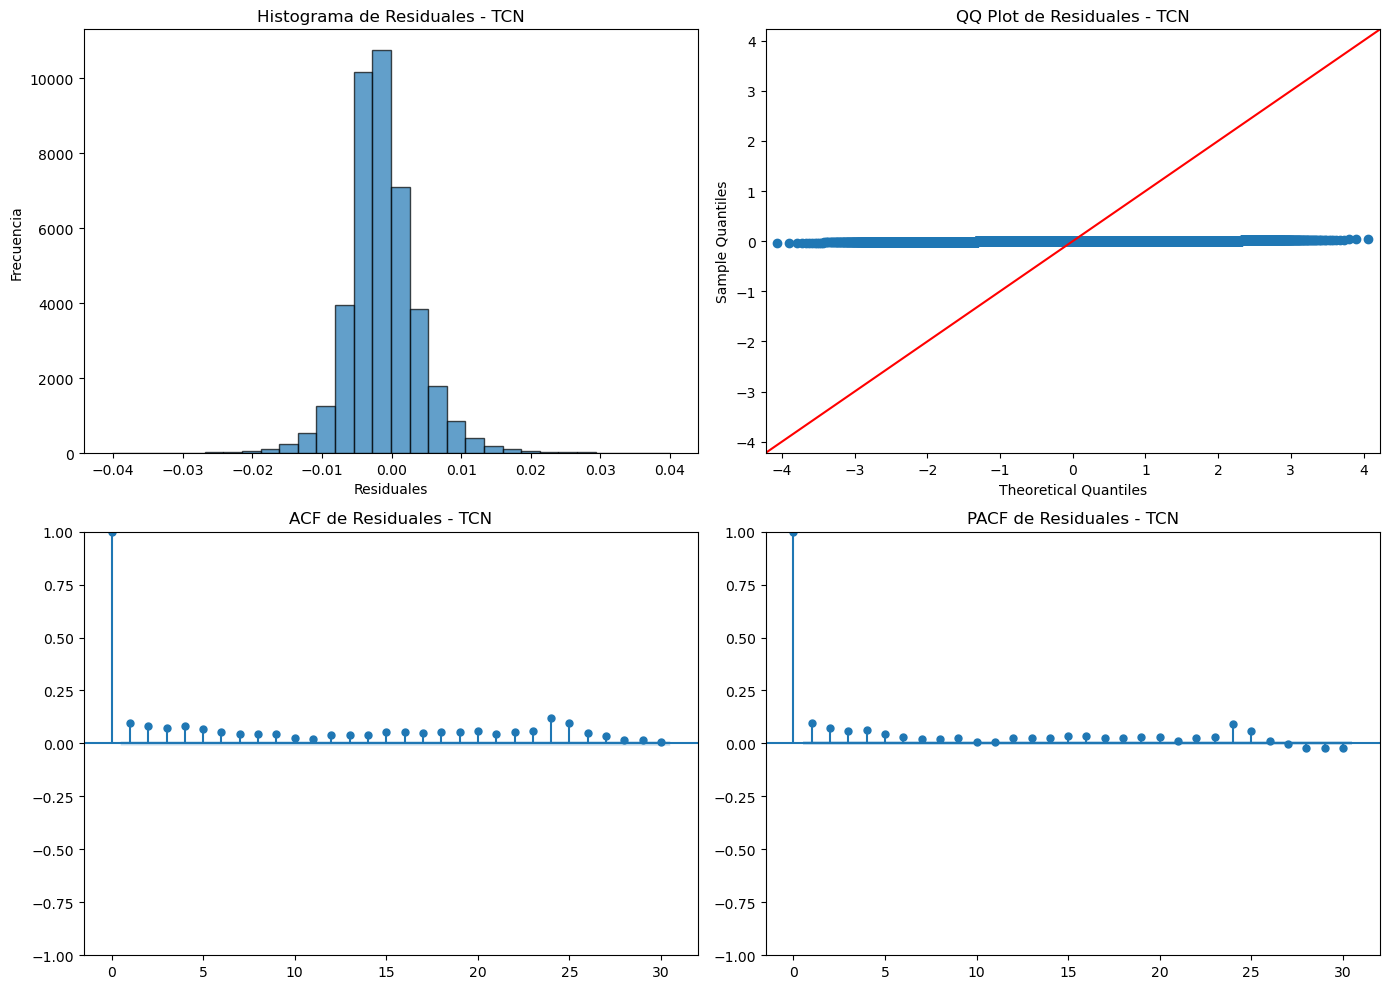

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

##############################################################################
# Función auxiliar para datos supervisados
##############################################################################
def create_supervised_data(series, window):
    """
    Convierte un array 1D 'series' en un conjunto de datos supervisado,
    con 'window' observaciones pasadas para predecir la siguiente.
    
    Retorna (X, y):
      - X: shape (muestras, window, 1)
      - y: shape (muestras,)
    """
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    X = np.array(X)
    y = np.array(y)
    # Reestructurar para la red temporal: (muestras, pasos de tiempo, features=1)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

##############################################################################
# Carga y preprocesamiento
##############################################################################
def load_and_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    data = df[['dt', 'loc', 'no2']]

    # Filtrar para loc=124 (ajusta si necesitas otra estación)
    data = data[data['loc'] == 124].drop(columns=['loc'])

    # Eliminar outliers extremos (percentiles 1 y 99)
    q1, q3 = data['no2'].quantile([0.01, 0.99])
    data = data[(data['no2'] >= q1) & (data['no2'] <= q3)]

    # Interpolar valores faltantes con método cúbico
    data['no2'] = data['no2'].interpolate(method='cubic')

    # Convertir 'dt' a datetime y establecer como índice
    data['dt'] = pd.to_datetime(data['dt'].astype(str), format='%Y%m%d%H')
    data.set_index('dt', inplace=True)
    data_hourly = data['no2'].asfreq('H').dropna()

    # División en entrenamiento, validación y prueba (70%, 15%, 15%)
    n = len(data_hourly)
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    train = data_hourly.iloc[:train_size]
    validation = data_hourly.iloc[train_size : train_size + val_size]
    test = data_hourly.iloc[train_size + val_size:]
    
    return train, validation, test

##############################################################################
# TCN sencillo en modo 'sliding window' (sin retroalimentar predicciones)
##############################################################################
def fast_sliding_window_forecast_tcn(train_series, test_series, window=24, epochs=3):
    """
    1. Entrena una sola vez (con train_series) un TCN básico de 2 capas Conv1D.
    2. Hace predicción en bloque sobre todo test, asumiendo que 'X_test' se arma
       con los valores reales (sin retroalimentar la predicción).
    """
    # Unimos train_series en un array
    train_arr = train_series.values
    
    # Convertimos la serie de entrenamiento a supervisado
    X_train, y_train = create_supervised_data(train_arr, window)
    
    # Definir la arquitectura TCN mínima
    model = Sequential()
    model.add(
        Conv1D(filters=32, kernel_size=3, dilation_rate=1,
               padding='causal', activation='relu', input_shape=(window, 1))
    )
    model.add(
        Conv1D(filters=32, kernel_size=3, dilation_rate=2,
               padding='causal', activation='relu')
    )
    model.add(Flatten())
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    
    # Entrenar (pocas épocas para ejemplificar)
    print("Entrenando el modelo TCN...")
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1)
    
    # Armar X_test, y_test con la serie de prueba
    test_arr = test_series.values
    X_test, y_test = create_supervised_data(test_arr, window)
    
    print("\nRealizando predicción en bloque (sin retroalimentar predicciones)...")
    y_pred = model.predict(X_test, verbose=1)
    
    # Alinear el vector de predicciones con las fechas de 'test_series'
    pred_index = test_series.index[window:]  # se "pierden" las primeras 'window' muestras
    predictions = pd.Series(y_pred.flatten(), index=pred_index)
    
    return predictions

##############################################################################
# Función para graficar resultados y análisis de residuos (6 gráficas)
##############################################################################
def plot_model_results(train, validation, test, prediction_series, model_residuals, model_name, rmse, mape):
    """
    La primera figura muestra:
       - (Subplot 1) Entrenamiento, validación, prueba vs. predicción
       - (Subplot 2) ACF de los residuales del test

    La segunda figura muestra (4 subplots):
       - Histograma de residuales
       - QQ Plot
       - ACF de residuales
       - PACF de residuales
    """
    # === FIGURA 1: PREDICCIÓN vs DATOS REALES + ACF de RESIDUALES ===
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1) Serie real + Predicción
    axes[0].plot(train.index, train.values, label="Entrenamiento")
    axes[0].plot(validation.index, validation.values, label="Validación")
    axes[0].plot(test.index, test.values, label="Prueba")
    axes[0].plot(prediction_series.index, prediction_series.values, '--',
                 label=f"Predicción {model_name}")
    
    axes[0].set_title(f"{model_name}\nRMSE: {rmse:.3f}, MAPE: {mape:.2f}%", 
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Fecha (Horaria)")
    axes[0].set_ylabel("Valores NO2")
    axes[0].legend()
    axes[0].grid(True)
    
    # 2) ACF de los residuales
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1])
    axes[1].set_title(f"ACF Residuales (Test) - {model_name}")
    
    plt.tight_layout()
    plt.show()
    
    # === FIGURA 2: ANÁLISIS COMPLETO DE RESIDUALES (4 SUBPLOTS) ===
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histograma
    axes[0, 0].hist(model_residuals.dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f"Histograma de Residuales - {model_name}")
    axes[0, 0].set_xlabel("Residuales")
    axes[0, 0].set_ylabel("Frecuencia")
    
    # QQ Plot
    sm.qqplot(model_residuals.dropna(), line='45', ax=axes[0, 1])
    axes[0, 1].set_title(f"QQ Plot de Residuales - {model_name}")
    
    # ACF
    plot_acf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 0])
    axes[1, 0].set_title(f"ACF de Residuales - {model_name}")
    
    # PACF
    plot_pacf(model_residuals.dropna(), lags=30, alpha=0.05, ax=axes[1, 1])
    axes[1, 1].set_title(f"PACF de Residuales - {model_name}")
    
    plt.tight_layout()
    plt.show()

##############################################################################
# Función principal
##############################################################################
def main():
    # Cambia la ruta a tu CSV:
    csv_path = r"C:\Users\MIGUEL HERRERA\Downloads\seoul_air_1988_2021.csv"
    
    # 1) Cargar y dividir los datos en train, validation, test
    train, validation, test = load_and_preprocess_data(csv_path)
    
    # 2) Unir train + validation para entrenar con más datos
    train_val = pd.concat([train, validation])
    
    # 3) Entrenar el modelo TCN y obtener predicciones en test
    window_size = 24  # ventana (ej. 24 horas)
    epochs = 3        # pocas épocas para ejemplo
    predictions = fast_sliding_window_forecast_tcn(train_val, test, window=window_size, epochs=epochs)
    
    # 4) Alinear test y predicciones, calcular métricas
    test_aligned = test.loc[predictions.index]  # recortamos el test al mismo índice de predicciones
    mse = mean_squared_error(test_aligned, predictions)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(test_aligned, predictions)
    mape = mean_absolute_percentage_error(test_aligned, predictions) * 100
    
    # 5) Residuales y prueba de Ljung-Box
    model_residuals = test_aligned - predictions
    lb_test = acorr_ljungbox(model_residuals.dropna(), lags=[20], return_df=True)
    ljung_box_pvalue = lb_test['lb_pvalue'].values[0]
    
    # 6) Imprimir resultados
    print("\n=== Métricas del modelo TCN ===")
    print(f" MSE :  {mse:.3f}")
    print(f" RMSE:  {rmse:.3f}")
    print(f" MAE :  {mae:.3f}")
    print(f" MAPE:  {mape:.2f}%")
    print(f" Ljung-Box p-value (lag=20): {ljung_box_pvalue:.4f}")
    
    # 7) Graficar (6 gráficas en total: 2 en la primera figura, 4 en la segunda)
    plot_model_results(
        train=train,
        validation=validation,
        test=test,
        prediction_series=predictions,
        model_residuals=model_residuals,
        model_name="TCN",
        rmse=rmse,
        mape=mape
    )

if __name__ == "__main__":
    main()

<div style="text-align: justify;">

Los resultados del modelo muestran que el error cuadrático medio (MSE) es prácticamente nulo, con un RMSE de 0.005, lo que indica una baja magnitud de error absoluto en la escala de los datos. Sin embargo, el MAPE (Mean Absolute Percentage Error) es del 14.33%, lo que sugiere que, en promedio, las predicciones difieren en un 14.33% del valor real, siendo un margen considerable. Además, el análisis de los residuales mediante la prueba de Ljung-Box revela que el p-valor para 20 rezagos es menor a 0.05 (p ≈ 0.0000), lo que indica la presencia de autocorrelación significativa en los errores. Este hallazgo se confirma con la ACF y PACF de los residuales, donde se observan correlaciones persistentes en múltiples rezagos, lo que sugiere que el modelo no ha capturado completamente la estructura temporal de los datos. Asimismo, el análisis gráfico de los residuales, incluyendo el histograma y el QQ-plot, muestra desviaciones respecto a la normalidad, lo que implica que los errores no siguen una distribución normal y podrían contener estructuras no modeladas. Estos resultados indican que, aunque la TCN logra minimizar el error cuadrático, su capacidad de generalización aún presenta limitaciones y podría beneficiarse de ajustes adicionales, como arquitecturas más profundas, selección optimizada de hiperparámetros o enfoques híbridos con modelos autoregresivos.

</div>

# Tabla de comparacion de resultados

<div style="text-align: justify;">

La tabla presenta el desempeño de distintos modelos de predicción con base en varias métricas. El MAPE (Mean Absolute Percentage Error) indica el porcentaje de error medio en relación con los valores reales, mientras que el MAE (Mean Absolute Error) mide el error absoluto medio en la misma escala de los datos. Por otro lado, el RMSE (Root Mean Square Error) y el MSE (Mean Squared Error) evalúan la magnitud de los errores, penalizando más los errores grandes debido a la elevación al cuadrado. El valor p del test de Ljung-Box (LB) permite verificar la independencia de los residuos, donde valores muy pequeños indican autocorrelación en los errores.



| Modelo        | MAPE   | MAE    | RMSE  | MSE      | LB (Valor p)  |
|--------------|--------|--------|-------|----------|--------------|
| *ES*¹       | 26.25% | 0.0062 | 0.008 | 0.000064 | < 0.0001     |
| *ES*²       | 27.83% | 0.0068 | 0.009 | 0.000082 | < 0.0001     |
| *ES-HW*¹    | 25.41% | 0.0059 | 0.008 | 0.000063 | < 0.0001     |
| *ES-HW*²    | 27.55% | 0.0065 | 0.009 | 0.000075 | < 0.0001     |
| *ES-HW*³    | 27.11% | 0.0067 | 0.009 | 0.000082 | < 0.0001     |
| GARCH       | 37.85% | 0.010  | 0.012 | 0.000144 | < 0.0001     |
| ARIMA       | 37.90% | 0.009  | 0.012 | 0.000144 | < 0.0001     |
| MLP         | 16.78% | 0.004  | 0.005 | 0.000025 | < 0.0001     |
| LSTM        | 16.03% | 0.004  | 0.005 | 0.000025 | < 0.0001     |
| TCN         | **14.33%** | **0.004**  | **0.005** | **0.000025** | **< 0.0001**     |


**Tabla 1:** Comparación de los resultados de los modelos de benchmark.

El modelo TCN (Temporal Convolutional Network) obtiene el menor MAPE (14.33%), lo que indica que es el modelo más preciso en términos de error porcentual. Le siguen LSTM (16.03%) y MLP (16.78%), mostrando que las redes neuronales superan a los métodos tradicionales en términos de desempeño. En contraste, los modelos tradicionales como ARIMA (37.90%) y GARCH (37.85%) presentan los peores valores de MAPE, lo que sugiere un rendimiento significativamente inferior a los modelos de aprendizaje profundo. Entre los métodos tradicionales de suavizamiento exponencial, el mejor resultado lo obtiene ES-HW (25.41%), aunque aún es superado por los modelos neuronales.

Todos los modelos presentan un valor p del test de Ljung-Box menor a 0.0001, lo que indica que los residuos tienen autocorrelación significativa. Esto sugiere que los modelos podrían beneficiarse de ajustes adicionales o enfoques más avanzados en el modelado de series temporales. Los resultados muestran que los modelos basados en redes neuronales (TCN, LSTM y MLP) superan ampliamente a los enfoques tradicionales (ARIMA, GARCH, ES). En particular, TCN es el modelo con el mejor desempeño, logrando la menor tasa de error. Sin embargo, la presencia de autocorrelación en los residuos sugiere que aún podrían implementarse mejoras, como ajustar hiperparámetros o incorporar arquitecturas híbridas para optimizar la predicción.

</div>


```{tableofcontents}
```
